
# Project P.7 Treasury Futures Options: Vol Regimes and Market Structure


### Group B 12: Aryaa Gunavante, Claire Kim, Divya Dehlan, Shreya Enaganti

In this project we ... 

___
### Imports

In [386]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.optimize import brentq, minimize

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)



### Helper Functions

Core utilities for:
- loading TY option and swaption data,
- converting delta vols to strike smiles via Black inversion,
- SABR calibration with ATM pinning ($\beta=0.5$),
- plotting and summary tables.

#### Data Loading 


In [387]:

DATA_DIR = 'data'
TY_FILE = f'{DATA_DIR}/ty_option_surfaces_p7.xlsx'
SWAPTION_FILE = f'{DATA_DIR}/swaption_smile_daily_2025.xlsx'

CONTRACT_SHEETS = {
    'M2025': 'CBT TY TY M2025',
    'H2026': 'CBT TY TY H2026',
    'M2026': 'CBT TY TY M2026',
}


def load_ty_contracts(path=TY_FILE):
    """
    Load TY futures option surface data for each contract month.

    Parameters
    ----------
    path : str
        Path to the Excel file containing TY option surface data.

    Returns
    -------
    dict[str, pd.DataFrame]
        Dictionary mapping contract codes (e.g. 'M2025') to their
        corresponding cleaned DataFrame.

    Notes
    -----
    Each sheet contains daily option surface observations with columns such as:
        - date
        - Future Price (futures level)
        - Expiration Option (time to maturity in years)
        - P25dvol, C50dvol, etc. (delta-based implied vol quotes)

    Dates are parsed and the data is sorted chronologically.
    """
    out = {}
    for short, sheet in CONTRACT_SHEETS.items():
        df = pd.read_excel(path, sheet_name=sheet)
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        out[short] = df
    return out


def load_swaption_data(path=SWAPTION_FILE):
    """
    Load swaption smile data used for comparison with TY options.

    Parameters
    ----------
    path : str
        Path to the swaption data Excel file.

    Returns
    -------
    merged : pd.DataFrame
        Dataset containing implied vols, forwards, and strikes merged by date.

    strike_cols : list[str]
        List of strike column names corresponding to smile points.

    Notes
    -----
    Data comes from three sheets:

        black_vol_pct
            Black implied volatilities quoted in percent.

        atm_forward
            ATM forward swap rate.

        absolute_strikes_pct
            Absolute strike levels.

    Vols are converted from percent to decimal for use in SABR and Black formulas.
    """
    vols = pd.read_excel(path, sheet_name='black_vol_pct')
    fwd = pd.read_excel(path, sheet_name='atm_forward')
    strikes = pd.read_excel(path, sheet_name='absolute_strikes_pct')

    for d in (vols, fwd, strikes):
        d['date'] = pd.to_datetime(d['date'])

    # Convert vol to decimal.
    strike_cols = [c for c in vols.columns if c != 'date']
    vols[strike_cols] = vols[strike_cols] / 100.0

    merged = vols.merge(fwd, on='date', how='inner').merge(strikes, on='date', how='inner', suffixes=('_vol', '_K'))
    return merged, strike_cols


def nearest_date(df, target_date):
    """
    Return the date in a dataset closest to a requested target date.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing a 'date' column.

    target_date : str or pd.Timestamp
        Desired reference date.

    Returns
    -------
    pd.Timestamp
        The date in the dataset closest to the requested date.
    """
    target_date = pd.Timestamp(target_date)
    i = np.argmin(np.abs(df['date'].values - target_date.to_datetime64()))
    return pd.Timestamp(df.loc[i, 'date'])


#### Numerical and SABR Computations

In [388]:
# Smile Construction 
def parse_delta_col(col_name):
    """
    Parse a delta-vol column name into option type and delta magnitude.

    Parameters
    ----------
    col_name : str
        Column name such as 'P25dvol' or 'C50dvol'.

    Returns
    -------
    cp : str
        'P' for put or 'C' for call.

    delta : float
        Absolute delta value (e.g. 0.25 for 25Δ).
    """
    cp = col_name[0]
    d = float(col_name[1:-4]) / 100.0
    return cp, d

def delta_to_strike(F, sigma, T, delta_abs, cp):
    """
    Convert delta-quoted option volatility to strike using the
    Black (1976) futures option delta inversion.

    Parameters
    ----------
    F : float
        Futures price.

    sigma : float
        Implied volatility (decimal).

    T : float
        Time to maturity (years).

    delta_abs : float
        Absolute delta level (e.g. 0.25).

    cp : str
        Option type: 'C' for call, 'P' for put.

    Returns
    -------
    float
        Implied strike corresponding to the delta quote.

    Notes
    -----
    Under the Black futures model:

        Call delta = N(d1)
        Put delta  = N(d1) - 1

    Using the market convention |Δ_put| = N(-d1), we invert to obtain K.

    Numerical guards ensure stability for extreme values.
    """

    sigma = max(float(sigma), 1e-8)
    T = max(float(T), 1e-8)

    # Clip delta to avoid infinities
    delta_abs = float(np.clip(delta_abs, 1e-6, 1 - 1e-6))

    q = norm.ppf(delta_abs)

    if cp.upper() == 'P':
        K = F * np.exp(q * sigma * np.sqrt(T) + 0.5 * sigma**2 * T)
    else:
        K = F * np.exp(-q * sigma * np.sqrt(T) + 0.5 * sigma**2 * T)

    return float(K)


def build_ty_smile_from_row(row):
    """
    Construct a strike-based volatility smile from a row of TY option data.
    Adds useful smile coordinates for analysis.
    """

    F = float(row['Future Price'])
    T = float(row['Expiration Option'])

    recs = []

    vol_cols = [
        c for c in row.index
        if isinstance(c, str) and c.endswith('dvol') and c[0] in ('P','C')
    ]

    for col in vol_cols:

        vol = row[col]

        if pd.isna(vol):
            continue

        cp, d_abs = parse_delta_col(col)

        K = delta_to_strike(F, vol, T, d_abs, cp)

        delta_signed = d_abs if cp == 'C' else -d_abs

        recs.append({
            'side': cp,
            'delta': delta_signed,
            'delta_abs': d_abs,
            'strike': K,
            'vol': float(vol),
            'label': col
        })

    smile = pd.DataFrame(recs)

    if smile.empty:
        return smile

    smile = smile.sort_values('strike').reset_index(drop=True)

    # useful smile coordinates
    smile['log_moneyness'] = np.log(smile['strike'] / F)

    smile['bp_from_atm'] = (smile['strike'] / F - 1.0) * 10000

    return smile

def interpolate_atm_vol(smile, F):
    xs = smile['strike'].to_numpy()
    ys = smile['vol'].to_numpy()
    order = np.argsort(xs)
    return float(np.interp(F, xs[order], ys[order]))

# Smile Analysis

def shape_metrics(smile, F):
    x = smile['log_moneyness'].to_numpy()
    y = smile['vol'].to_numpy()
    coef = np.polyfit(x, y, 2)

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    return {
        'atm_vol_interp': interpolate_atm_vol(smile, F),
        'skew_coef': float(coef[1]),
        'curvature_coef': float(coef[0]),
        'left_minus_right_1pct': float(np.interp(-0.01, x_sorted, y_sorted) - np.interp(0.01, x_sorted, y_sorted)),
    }

def compute_smile_shape_metrics(smile_df, F):
    """
    Compute simple shape statistics of a volatility smile.

    Parameters
    ----------
    smile_df : DataFrame
        Must contain columns 'K' (strike) and 'iv' (implied vol)

    F : float
        Forward/futures price

    Returns
    -------
    dict
        Dictionary containing:
        - atm_vol
        - skew
        - curvature
        - left_vs_right
    """

    x = np.log(smile_df['K'] / F)
    y = smile_df['iv']

    coef = np.polyfit(x, y, 2)

    x_sorted = np.sort(x)
    y_sorted = y[np.argsort(x)]

    return {
        "atm_vol": float(np.interp(0.0, x_sorted, y_sorted)),
        "skew": float(coef[1]),
        "curvature": float(coef[0]),
        "left_minus_right": float(
            np.interp(-0.01, x_sorted, y_sorted) -
            np.interp(0.01, x_sorted, y_sorted)
        ),
    }

def normalize_smile(K, vol, F, T):
    """
    Normalize a volatility smile for cross-product comparison.

    Parameters
    ----------
    K : array
        Strikes

    vol : array
        Implied vols

    F : float
        Forward price

    T : float
        Time to maturity

    Returns
    -------
    DataFrame
        Normalized smile coordinates.
    """

    K = np.asarray(K)
    vol = np.asarray(vol)

    order = np.argsort(K)
    K = K[order]
    vol = vol[order]

    atm = float(np.interp(F, K, vol))

    x = np.log(K / F) / (atm * np.sqrt(T))
    y = vol / atm

    return pd.DataFrame({
        "x_norm": x,
        "vol_norm": y,
        "strike": K,
        "vol": vol,
        "atm": atm
    })

def normalized_shape_metrics(norm_df):
    
    x = norm_df['x_norm'].to_numpy()
    y = norm_df['vol_norm'].to_numpy()

    coef = np.polyfit(x, y, 2)

    order = np.argsort(x)
    x_s = x[order]
    y_s = y[order]

    return {
        "skew": float(coef[1]),
        "curvature": float(coef[0]),
        "left_tail": float(np.interp(-1.0, x_s, y_s)),
        "right_tail": float(np.interp(1.0, x_s, y_s))
    }

# SABR Model 

def _sabr_atm(F, T, alpha, beta, rho, nu):
    """
    Compute ATM implied volatility under the SABR model.

    Parameters
    ----------
    F : float
        Forward/futures price.

    T : float
        Time to maturity (years).

    alpha : float
        SABR volatility level parameter.

    beta : float
        SABR elasticity parameter.

    rho : float
        Correlation between forward and volatility processes.

    nu : float
        Volatility-of-volatility parameter.

    Returns
    -------
    float
        SABR-implied ATM volatility.

    Notes
    -----
    This is the closed-form ATM expansion. It is used to "pin" the calibration 
    so the SABR model matches the market ATM volatility exactly.
    """
    B = (
        (1 - beta) ** 2 * alpha ** 2 / (24 * F ** (2 - 2 * beta))
        + rho * beta * nu * alpha / (4 * F ** (1 - beta))
        + (2 - 3 * rho ** 2) * nu ** 2 / 24
    )
    # ATM SABR implied volatility
    return alpha / F ** (1 - beta) * (1 + B * T)


def sabr_vol(F, K, T, alpha, beta, rho, nu):
    """
    Compute SABR implied volatility for arbitrary strikes.

    Parameters
    ----------
    F : float
        Forward/futures price.

    K : float or array
        Option strike(s).

    T : float
        Time to maturity.

    alpha, beta, rho, nu : floats
        SABR model parameters.

    Returns
    -------
    float or ndarray
        SABR-implied volatility.

    Notes
    -----
    Implements the Hagan (2002) lognormal SABR approximation.

    Handles the ATM case separately to avoid numerical instability.
    """
    K = np.atleast_1d(np.asarray(K, dtype=float))
    out = np.zeros(K.shape, dtype=float)

    for i, Ki in enumerate(K.flat):

        if abs(Ki - F) < max(1e-9, F * 1e-9):
            # Handle ATM case separately
            out.flat[i] = _sabr_atm(F, T, alpha, beta, rho, nu)
            continue
        
        # Common SABR terms
        FK = (F * Ki) ** ((1 - beta) / 2)
        lg = np.log(F / Ki)
        # z variable in SABR formula
        z = (nu / alpha) * FK * lg
        # Chi(z) term
        inner = np.sqrt(1 - 2 * rho * z + z * z) + z - rho
        # Guard against invalid values
        if inner <= 1e-14:
            out.flat[i] = np.nan
            continue

        chi = np.log(inner / (1 - rho))
        # z/chi term stabilizes small-z behavior
        zchi = z / chi if abs(chi) > 1e-12 else 1.0

        # Denominator correction for beta ≠ 1
        denom = FK * (1 + (1 - beta) ** 2 / 24 * lg ** 2 + (1 - beta) ** 4 / 1920 * lg ** 4)
        B = (
            (1 - beta) ** 2 * alpha ** 2 / (24 * (F * Ki) ** (1 - beta))
            + rho * beta * nu * alpha / (4 * FK)
            + (2 - 3 * rho ** 2) * nu ** 2 / 24
        )
        out.flat[i] = alpha / denom * zchi * (1 + B * T)

    return float(out[0]) if out.size == 1 else out


def solve_alpha_from_atm(F, T, beta, rho, nu, sigma_atm):
    """
    Solve for the SABR alpha parameter that matches the market ATM volatility.

    Parameters
    ----------
    F : float
        Forward price.

    T : float
        Time to maturity.

    beta, rho, nu : floats
        SABR parameters.

    sigma_atm : float
        Observed ATM implied volatility.

    Returns
    -------
    float
        Alpha parameter consistent with the ATM volatility.

    Notes
    -----
    Uses Brent root-finding to solve:

        SABR_ATM(alpha) = sigma_atm
    """
    def f(a):
        return _sabr_atm(F, T, a, beta, rho, nu) - sigma_atm

    lo, hi = 1e-8, 2.0
    flo, fhi = f(lo), f(hi)

    # Expand search interval if needed
    guard = 0
    while flo * fhi > 0 and guard < 20:
        hi *= 2.0
        fhi = f(hi)
        guard += 1

    if flo * fhi > 0:
        return np.nan

    try:
        return brentq(f, lo, hi, xtol=1e-12, rtol=1e-10, maxiter=200)
    except Exception:
        return np.nan


def calibrate_sabr_atm_pinned(F, T, K, sigma_mkt, beta=0.5, init=None):
    K = np.asarray(K, dtype=float)
    sigma_mkt = np.asarray(sigma_mkt, dtype=float)

    m = np.isfinite(K) & np.isfinite(sigma_mkt) & (K > 0) & (sigma_mkt > 0)
    K = K[m]
    sigma_mkt = sigma_mkt[m]

    if len(K) < 5:
        return {'alpha': np.nan, 'rho': np.nan, 'nu': np.nan, 'rmse': np.nan, 'sse': np.nan, 'n': len(K)}

    # Use average of nearest-to-ATM points for ATM vol pin.
    atm_idx = np.argsort(np.abs(K - F))[:2]
    sigma_atm = float(np.mean(sigma_mkt[atm_idx]))

    def objective(x):
        rho, nu = x
        if abs(rho) >= 0.999 or nu <= 1e-6:
            return 1e10
        alpha = solve_alpha_from_atm(F, T, beta, rho, nu, sigma_atm)
        if not np.isfinite(alpha) or alpha <= 0:
            return 1e10
        fit = sabr_vol(F, K, T, alpha, beta, rho, nu)
        if np.any(~np.isfinite(fit)):
            return 1e10
        err = fit - sigma_mkt
        return float(np.sum(err ** 2))

    starts = []
    if init is not None and np.all(np.isfinite(init)):
        starts.append(np.array(init, dtype=float))
    starts += [
        np.array([0.0, 0.35]),
        np.array([-0.2, 0.6]),
        np.array([0.2, 0.5]),
        np.array([-0.4, 1.0]),
    ]

    best = None
    for x0 in starts:
        try:
            res = minimize(
                objective,
                x0=x0,
                method='L-BFGS-B',
                bounds=[(-0.999, 0.999), (1e-4, 10.0)],
                options={'maxiter': 600},
            )
            if best is None or res.fun < best.fun:
                best = res
        except Exception:
            pass

    if best is None:
        return {'alpha': np.nan, 'rho': np.nan, 'nu': np.nan, 'rmse': np.nan, 'sse': np.nan, 'n': len(K)}

    rho, nu = best.x
    alpha = solve_alpha_from_atm(F, T, beta, rho, nu, sigma_atm)
    fit = sabr_vol(F, K, T, alpha, beta, rho, nu)
    rmse = float(np.sqrt(np.mean((fit - sigma_mkt) ** 2)))

    return {
        'alpha': float(alpha),
        'rho': float(rho),
        'nu': float(nu),
        'rmse': rmse,
        'sse': float(np.sum((fit - sigma_mkt) ** 2)),
        'n': int(len(K)),
        'sigma_atm': sigma_atm,
        'fit': fit,
        'K': K,
        'sigma_mkt': sigma_mkt,
    }


def calibrate_contract_daily(df_contract, contract_name, beta=0.5, step=1):
    rows = []
    prev_init = None
    for i in range(0, len(df_contract), step):
        row = df_contract.iloc[i]
        smile = build_ty_smile_from_row(row)
        res = calibrate_sabr_atm_pinned(
            F=float(row['Future Price']),
            T=float(row['Expiration Option']),
            K=smile['strike'].values,
            sigma_mkt=smile['vol'].values,
            beta=beta,
            init=prev_init,
        )

        if np.isfinite(res.get('rho', np.nan)) and np.isfinite(res.get('nu', np.nan)):
            prev_init = [res['rho'], res['nu']]

        rows.append({
            'contract': contract_name,
            'date': pd.Timestamp(row['date']),
            'F': float(row['Future Price']),
            'T': float(row['Expiration Option']),
            'atm_vol': float((row.get('P50dvol', np.nan) + row.get('C50dvol', np.nan)) / 2),
            'alpha': res['alpha'],
            'rho': res['rho'],
            'nu': res['nu'],
            'rmse': res['rmse'],
            'n_points': res['n'],
        })

    out = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)
    return out

def sabr_objective_weighted(F, K, T, sigma_mkt, alpha, beta, rho, nu):
    """
    Weighted calibration error giving higher weight to near-ATM strikes.
    """

    fit = sabr_vol(F, K, T, alpha, beta, rho, nu)

    # Weight by log-moneyness
    w = 1 / (1 + np.log(K / F) ** 2)

    err = fit - sigma_mkt

    return np.sum(w * err ** 2)

def plot_sabr_fit(F, K, sigma_mkt, alpha, beta, rho, nu, T):
    """
    Plot market smile vs SABR fitted smile.
    """

    Kgrid = np.linspace(min(K), max(K), 200)
    sabr_fit = sabr_vol(F, Kgrid, T, alpha, beta, rho, nu)

    plt.figure(figsize=(8,5))

    plt.scatter(K, sigma_mkt, label="Market vols")
    plt.plot(Kgrid, sabr_fit, label="SABR fit")

    plt.axvline(F, linestyle="--", color="black", label="Forward")

    plt.xlabel("Strike")
    plt.ylabel("Implied vol")
    plt.title("SABR Calibration Fit")
    plt.legend()

    plt.show()

# Black Model Utilities

def black_delta_futures(F, K, sigma, T, cp='C'):
    if T <= 0 or sigma <= 0:
        if cp == 'C':
            return 1.0 if F > K else 0.0
        return -1.0 if F < K else 0.0
    d1 = (np.log(F / K) + 0.5 * sigma * sigma * T) / (sigma * np.sqrt(T))
    if cp == 'C':
        return float(norm.cdf(d1))
    return float(norm.cdf(d1) - 1.0)


def black_vega_futures(F, K, sigma, T):
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = (np.log(F / K) + 0.5 * sigma * sigma * T) / (sigma * np.sqrt(T))
    return float(F * norm.pdf(d1) * np.sqrt(T))



## Load Data


In [389]:

ty_contracts = load_ty_contracts(TY_FILE)
swaption_merged, swaption_offsets = load_swaption_data(SWAPTION_FILE)

for k, v in ty_contracts.items():
    print(k, v['date'].min().date(), '->', v['date'].max().date(), '| rows =', len(v))
print('Swaption rows:', len(swaption_merged))


M2025 2025-03-03 -> 2025-05-22 | rows = 59
H2026 2025-11-03 -> 2026-02-19 | rows = 78
M2026 2026-01-02 -> 2026-02-27 | rows = 41
Swaption rows: 21


### Data Preview

Quick sanity check on shapes, columns, and the first few rows.


In [390]:
print('TY contracts:')
for k, v in ty_contracts.items():
    print(f'  {k}: shape={v.shape}')
    print('  columns:', list(v.columns))
    display(v.head(3))

print('Swaption merged:')
print('  shape=', swaption_merged.shape)
print('  columns:', list(swaption_merged.columns))
display(swaption_merged.head(3))

print('Swaption offsets (vol columns):', swaption_offsets)


TY contracts:
  M2025: shape=(59, 34)
  columns: ['date', 'Future Price', 'Expiration Option', 'Expiration Future', 'P15dvol', 'P20dvol', 'P25dvol', 'P30dvol', 'P35dvol', 'P40dvol', 'P45dvol', 'P50dvol', 'P55dvol', 'P60dvol', 'P65dvol', 'P70dvol', 'P75dvol', 'P80dvol', 'P85dvol', 'C15dvol', 'C20dvol', 'C25dvol', 'C30dvol', 'C35dvol', 'C40dvol', 'C45dvol', 'C50dvol', 'C55dvol', 'C60dvol', 'C65dvol', 'C70dvol', 'C75dvol', 'C80dvol', 'C85dvol']


,date,Future Price,Expiration Option,Expiration Future,P15dvol,P20dvol,P25dvol,P30dvol,P35dvol,P40dvol,P45dvol,P50dvol,P55dvol,P60dvol,P65dvol,P70dvol,P75dvol,P80dvol,P85dvol,C15dvol,C20dvol,C25dvol,C30dvol,C35dvol,C40dvol,C45dvol,C50dvol,C55dvol,C60dvol,C65dvol,C70dvol,C75dvol,C80dvol,C85dvol
0,2025-03-03,111.40625,0.222493,0.293151,0.064559,0.063955,0.064298,0.064598,0.064343,0.064261,0.065092,0.065408,0.066358,0.066882,0.067628,0.068128,0.069242,0.070470,0.072362,0.071820,0.070211,0.069009,0.068045,0.067471,0.066791,0.066174,0.065345,0.065008,0.064082,0.064452,0.064605,0.064188,0.063923,0.064771
1,2025-03-04,111.25000,0.219753,0.290411,0.064550,0.064381,0.064131,0.064327,0.064642,0.064417,0.064940,0.065474,0.065587,0.065916,0.066500,0.067053,0.068476,0.069387,0.071460,0.071240,0.069276,0.068101,0.066888,0.066437,0.065766,0.065610,0.065373,0.064835,0.064460,0.064623,0.064260,0.064109,0.064382,0.064867
2,2025-03-05,110.87500,0.217014,0.287671,0.065287,0.064251,0.063971,0.064292,0.064043,0.063703,0.063939,0.064174,0.064338,0.064586,0.065016,0.065825,0.066691,0.067297,0.069274,0.069087,0.067192,0.066547,0.065631,0.064917,0.064533,0.064308,0.064129,0.063894,0.063659,0.064152,0.064297,0.063854,0.064459,0.065507


  H2026: shape=(78, 34)
  columns: ['date', 'Future Price', 'Expiration Option', 'Expiration Future', 'P15dvol', 'P20dvol', 'P25dvol', 'P30dvol', 'P35dvol', 'P40dvol', 'P45dvol', 'P50dvol', 'P55dvol', 'P60dvol', 'P65dvol', 'P70dvol', 'P75dvol', 'P80dvol', 'P85dvol', 'C15dvol', 'C20dvol', 'C25dvol', 'C30dvol', 'C35dvol', 'C40dvol', 'C45dvol', 'C50dvol', 'C55dvol', 'C60dvol', 'C65dvol', 'C70dvol', 'C75dvol', 'C80dvol', 'C85dvol']


,date,Future Price,Expiration Option,Expiration Future,P15dvol,P20dvol,P25dvol,P30dvol,P35dvol,P40dvol,P45dvol,P50dvol,P55dvol,P60dvol,P65dvol,P70dvol,P75dvol,P80dvol,P85dvol,C15dvol,C20dvol,C25dvol,C30dvol,C35dvol,C40dvol,C45dvol,C50dvol,C55dvol,C60dvol,C65dvol,C70dvol,C75dvol,C80dvol,C85dvol
0,2025-11-03,112.609375,0.299205,0.375342,0.050809,0.049898,0.049059,0.048668,0.048479,0.048799,0.048669,0.048589,0.048748,0.049272,0.049324,0.050641,0.051574,0.052070,0.054415,0.053696,0.051954,0.051406,0.050222,0.049317,0.049146,0.048639,0.048573,0.048725,0.048722,0.048483,0.048727,0.049166,0.050138,0.051028
1,2025-11-04,112.718750,0.296466,0.372603,0.049827,0.049356,0.048996,0.048603,0.048240,0.048346,0.048843,0.048818,0.049102,0.049893,0.050766,0.051285,0.052365,0.054099,0.055177,0.054900,0.053879,0.052045,0.051160,0.050584,0.049680,0.048923,0.048855,0.048726,0.048281,0.048227,0.048750,0.049031,0.049505,0.049919
2,2025-11-05,112.250000,0.293726,0.369863,0.050609,0.050160,0.049370,0.049073,0.048934,0.048593,0.048668,0.049042,0.049386,0.049690,0.050036,0.050538,0.051506,0.053204,0.055364,0.054570,0.053020,0.051254,0.050421,0.049945,0.049612,0.049318,0.048945,0.048651,0.048592,0.049038,0.049050,0.049584,0.050302,0.050681


  M2026: shape=(41, 34)
  columns: ['date', 'Future Price', 'Expiration Option', 'Expiration Future', 'P15dvol', 'P20dvol', 'P25dvol', 'P30dvol', 'P35dvol', 'P40dvol', 'P45dvol', 'P50dvol', 'P55dvol', 'P60dvol', 'P65dvol', 'P70dvol', 'P75dvol', 'P80dvol', 'P85dvol', 'C15dvol', 'C20dvol', 'C25dvol', 'C30dvol', 'C35dvol', 'C40dvol', 'C45dvol', 'C50dvol', 'C55dvol', 'C60dvol', 'C65dvol', 'C70dvol', 'C75dvol', 'C80dvol', 'C85dvol']


,date,Future Price,Expiration Option,Expiration Future,P15dvol,P20dvol,P25dvol,P30dvol,P35dvol,P40dvol,P45dvol,P50dvol,P55dvol,P60dvol,P65dvol,P70dvol,P75dvol,P80dvol,P85dvol,C15dvol,C20dvol,C25dvol,C30dvol,C35dvol,C40dvol,C45dvol,C50dvol,C55dvol,C60dvol,C65dvol,C70dvol,C75dvol,C80dvol,C85dvol
0,2026-01-02,112.093750,0.384137,0.457534,0.049653,0.048650,0.047855,0.047035,0.047060,0.047182,0.047018,0.046648,0.046334,0.046371,0.046487,0.047453,0.048384,0.049920,0.051049,0.050656,0.049680,0.048066,0.047170,0.046455,0.046356,0.046333,0.046769,0.047104,0.047145,0.047043,0.047269,0.048019,0.049104,0.049748
1,2026-01-05,112.296875,0.375918,0.449315,0.049379,0.048357,0.047578,0.047085,0.046647,0.046614,0.046216,0.046692,0.046757,0.047005,0.047630,0.048298,0.049113,0.050404,0.052486,0.051730,0.050043,0.048783,0.048163,0.047419,0.046864,0.046777,0.046558,0.046324,0.046683,0.046634,0.047275,0.047676,0.048629,0.049707
2,2026-01-06,112.203125,0.373178,0.446575,0.047635,0.046882,0.046703,0.046151,0.045510,0.045434,0.045373,0.045922,0.046153,0.046203,0.047010,0.047611,0.048394,0.049169,0.050848,0.050410,0.048534,0.048365,0.047405,0.046833,0.045972,0.046223,0.045723,0.045390,0.045454,0.045570,0.046364,0.046825,0.046970,0.047908


Swaption merged:
  shape= (21, 24)
  columns: ['date', '-300_vol', '-200_vol', '-100_vol', '-50_vol', '-25_vol', '0_vol', '25_vol', '50_vol', '100_vol', '200_vol', '300_vol', 'atm_fwd_pct', '-300_K', '-200_K', '-100_K', '-50_K', '-25_K', '0_K', '25_K', '50_K', '100_K', '200_K', '300_K']


,date,-300_vol,-200_vol,-100_vol,-50_vol,-25_vol,0_vol,25_vol,50_vol,100_vol,200_vol,300_vol,atm_fwd_pct,-300_K,-200_K,-100_K,-50_K,-25_K,0_K,25_K,50_K,100_K,200_K,300_K
0,2025-04-01,0.8567,0.5135,0.3726,0.3306,0.3151,0.3028,0.2935,0.2870,0.2805,0.2831,0.2935,3.57,0.57,1.57,2.57,3.07,3.32,3.57,3.82,4.07,4.57,5.57,6.57
1,2025-04-02,0.9032,0.5276,0.3792,0.3350,0.3185,0.3055,0.2955,0.2885,0.2813,0.2833,0.2936,3.52,0.52,1.52,2.52,3.02,3.27,3.52,3.77,4.02,4.52,5.52,6.52
2,2025-04-03,1.1018,0.5849,0.4133,0.3637,0.3451,0.3304,0.3190,0.3107,0.3015,0.3011,0.3102,3.35,0.35,1.35,2.35,2.85,3.10,3.35,3.60,3.85,4.35,5.35,6.35


Swaption offsets (vol columns): [-300, -200, -100, -50, -25, 0, 25, 50, 100, 200, 300]


# Question 1: Implied Vol Surface Construction

The provided data gives implied volatilities by delta (e.g., 25-delta put, 50-delta put). Convert these to strike-based smiles.

a) For a representative date early in the M2025 sample, invert the Black delta formula to recover the strike corresponding to each delta point. Display the smile as implied vol vs. strike.

b) As a concrete starting point using an event from C.8.1, plot the smile for three dates around the April 2025 tariff episode (one day before, shock day, pause day). Comment on how the shape changes, not just the level.

c) Compare the TY option smile to the 1Yx5Y swaption smile from C.8.1 on the same date. Choose a normalization that makes the comparison meaningful given different ATM levels. Are there visible differences in skew or curvature?

Delta-to-strike inversion used:
- Put: $K = F \exp\!\left(\Phi^{-1}(\Delta_{\text{put,abs}})\,\sigma\sqrt{T} + \tfrac{1}{2}\sigma^2 T\right)$
- Call: $K = F \exp\!\left(-\Phi^{-1}(\Delta_{\text{call}})\,\sigma\sqrt{T} + \tfrac{1}{2}\sigma^2 T\right)$


## Q1(a)

We pick the earliest date in the M2025 TY options sample and convert each delta-quoted vol point (e.g., `P25dvol`, `C50dvol`) into a strike using the Black futures delta inversion. This produces a strike-based smile `(K, iv)` for that date, which we then plot.


In [391]:
# Extract the M2025 contract dataset
m2025 = ty_contracts['M2025'].copy()
# Select the earliest available observation date
rep_date = m2025['date'].min()
rep_row = m2025.loc[m2025['date'] == rep_date].iloc[0]
# Convert the delta-quoted vols in this row into strike-vol pairs.
rep_smile = build_ty_smile_from_row(rep_row)

print("First 10 strike-converted smile points:")
print(
    rep_smile[['side','delta','strike','vol']]
    .round(6)
    .head(10)
    .to_string(index=False)
)


First 10 strike-converted smile points:
side  delta     strike      vol
   C   0.85 107.984217 0.064771
   P  -0.15 107.995080 0.064559
   P  -0.20 108.662769 0.063955
   C   0.80 108.664100 0.063923
   P  -0.25 109.200633 0.064298
   C   0.75 109.204283 0.064188
   C   0.70 109.691004 0.064605
   P  -0.30 109.691182 0.064598
   C   0.65 110.159712 0.064452
   P  -0.35 110.161723 0.064343


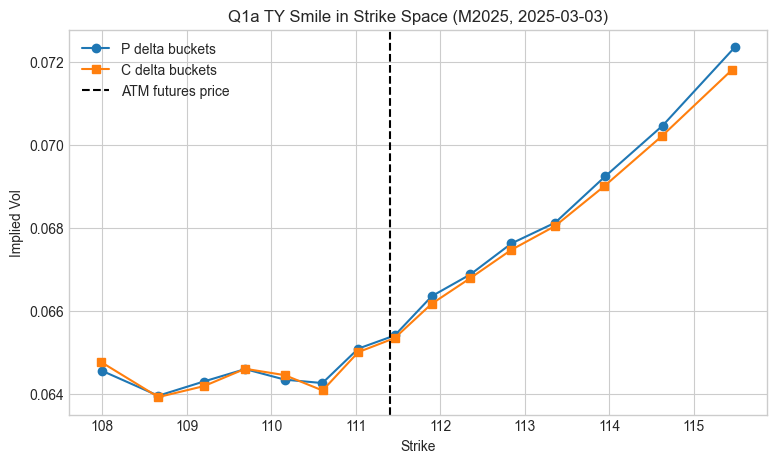

,side,delta,delta_abs,strike,vol,label,log_moneyness,bp_from_atm
0,C,0.85,0.85,107.984217,0.064771,C85dvol,-0.031198,-307.167029
1,P,-0.15,0.15,107.995080,0.064559,P15dvol,-0.031098,-306.191961
2,P,-0.20,0.20,108.662769,0.063955,P20dvol,-0.024934,-246.259138
3,C,0.80,0.80,108.664100,0.063923,C80dvol,-0.024922,-246.139671
4,P,-0.25,0.25,109.200633,0.064298,P25dvol,-0.019997,-197.979664
5,C,0.75,0.75,109.204283,0.064188,C75dvol,-0.019963,-197.652033
6,C,0.70,0.70,109.691004,0.064605,C70dvol,-0.015516,-153.963211
7,P,-0.30,0.30,109.691182,0.064598,P30dvol,-0.015514,-153.947154
8,C,0.65,0.65,110.159712,0.064452,C65dvol,-0.011252,-111.891183
9,P,-0.35,0.35,110.161723,0.064343,P35dvol,-0.011234,-111.710730


In [392]:
# Separate calls and puts
calls = rep_smile[rep_smile['side'] == 'C']
puts  = rep_smile[rep_smile['side'] == 'P']

# Plot the strike-based volatility smile
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(
    puts['strike'], puts['vol'],
    'o-', lw=1.5, label='P delta buckets'
)

ax.plot(
    calls['strike'], calls['vol'],
    's-', lw=1.5, label='C delta buckets'
)

# ATM futures level
ax.axvline(
    rep_row['Future Price'],
    color='black',
    linestyle='--',
    label='ATM futures price'
)

ax.set_title(f"Q1a TY Smile in Strike Space (M2025, {rep_date.date()})")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Vol")

ax.legend()

plt.show()


rep_smile.head(10)


The reconstructed strike-based smile shows a clear upward skew, with implied volatility increasing for higher strikes relative to the ATM futures level. This indicates stronger demand for upside rate protection in Treasury futures options.

## Q1(b) 

To analyze how the volatility smile evolves around the April 2025 tariff episode, we plot the strike-based TY option smile for three key dates: the day before the shock (April 1), the shock day (April 3), and the policy pause announcement (April 9).

In [393]:
# Event dates discussed in class
event_targets = {
    'Pre-tariff (Apr 1)': '2025-04-01',
    'Tariff shock (Apr 3)': '2025-04-03',
    'Pause (Apr 9)': '2025-04-09',
}

# Find nearest available dates in dataset
event_dates = {k: nearest_date(m2025, v) for k, v in event_targets.items()}

print("Selected event dates:")
for k, d in event_dates.items():
    print(f"{k}: {d.date()}")

# Containers for diagnostics
shape_stats = []


Selected event dates:
Pre-tariff (Apr 1): 2025-04-01
Tariff shock (Apr 3): 2025-04-03
Pause (Apr 9): 2025-04-09


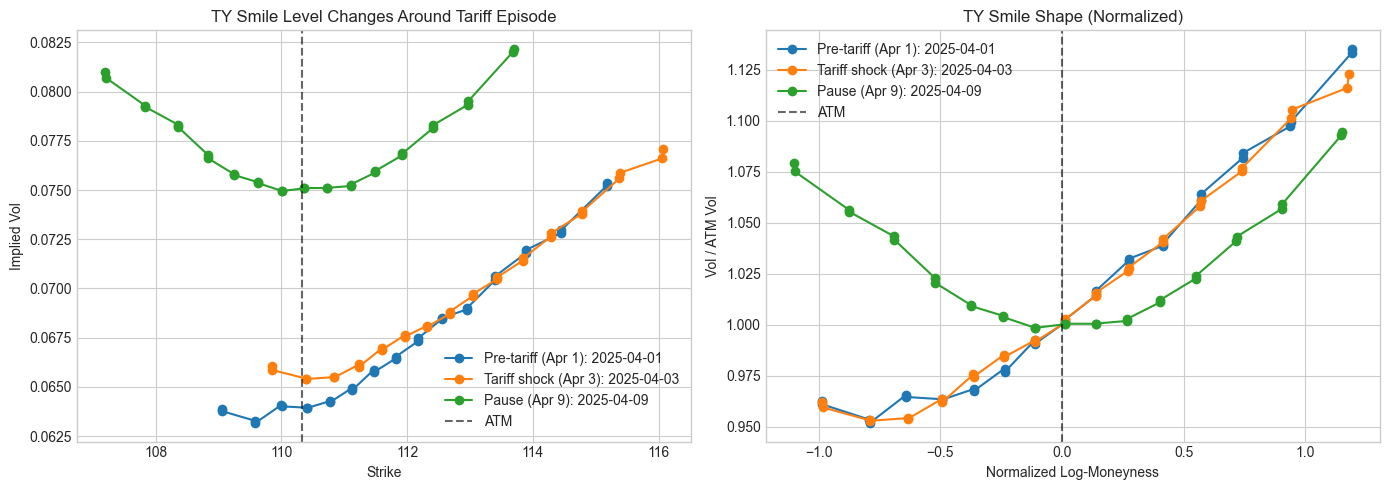


Q1b Smile Shape Diagnostics:
                           date   atm_vol      skew  curvature  left_minus_right
label                                                                           
Pre-tariff (Apr 1)   2025-04-01  0.066366  0.210498   3.223750         -0.004706
Tariff shock (Apr 3) 2025-04-03  0.068640  0.211304   2.667000         -0.004522
Pause (Apr 9)        2025-04-09  0.075072  0.002746   7.640427          0.000041


In [394]:
# Plot Smiles: Raw and Normalized

fig, axes = plt.subplots(1, 2, figsize=(14,5))

for label, d in event_dates.items():

    row = m2025.loc[m2025['date'] == d].iloc[0]
    smile = build_ty_smile_from_row(row)

    # prepare columns used in metrics
    smile['log_moneyness'] = np.log(smile['strike'] / row['Future Price'])

    # Raw smile (level + shape)
    axes[0].plot(
        smile['strike'],
        smile['vol'],
        marker='o',
        linewidth=1.5,
        label=f"{label}: {d.date()}"
    )

    # Normalized smile (shape only)
    normalized = normalize_smile(
        smile['strike'],
        smile['vol'],
        row['Future Price'],
        row['Expiration Option']
    )

    axes[1].plot(
        normalized['x_norm'],
        normalized['vol_norm'],
        marker='o',
        linewidth=1.5,
        label=f"{label}: {d.date()}"
    )

    # compute shape diagnostics
    metrics = shape_metrics(smile, row['Future Price'])

    shape_stats.append({
        "label": label,
        "date": d,
        "atm_vol": metrics['atm_vol_interp'],
        "skew": metrics['skew_coef'],
        "curvature": metrics['curvature_coef'],
        "left_minus_right": metrics['left_minus_right_1pct'],
    })

# ATM reference lines
# ATM strike in raw smile
axes[0].axvline(
    row['Future Price'],
    linestyle='--',
    color='black',
    alpha=0.6,
    label='ATM'
)

# ATM log-moneyness = 0 in normalized smile
axes[1].axvline(
    0,
    linestyle='--',
    color='black',
    alpha=0.6,
    label='ATM'
)

# Raw smile formatting
axes[0].set_title("TY Smile Level Changes Around Tariff Episode")
axes[0].set_xlabel("Strike")
axes[0].set_ylabel("Implied Vol")
axes[0].legend()

# Normalized smile formatting
axes[1].set_title("TY Smile Shape (Normalized)")
axes[1].set_xlabel("Normalized Log-Moneyness")
axes[1].set_ylabel("Vol / ATM Vol")
axes[1].legend()

plt.tight_layout()
plt.show()

# Shape diagnostics table
shape_df = pd.DataFrame(shape_stats).set_index("label").sort_values("date")

print("\nQ1b Smile Shape Diagnostics:")
print(shape_df.round(6))

The results show that implied volatility rises during the event window. ATM volatility increases from approximately 6.64% on April 1 to 6.86% on the shock day and further to 7.51% by April 9. This reflects elevated uncertainty in interest-rate markets during the tariff announcement and subsequent policy response.

The normalized smiles indicate how the shape evolves. Before and during the shock, the smile has a right skew, with higher volatility for higher strikes. This is reflected in the positive skew coefficient and the negative left-minus-right wing difference. 

After the policy pause announcement, the skew collapses and the smile becomes more symmetric. Options far from the money on both sides are characterized by much higher implied volatility relative to ATM. Such behavior suggests heightened demand for tail risk protection in both directions following the event.

### Q1(c)

To compare the volatility smiles of TY options and 1Yx5Y swaptions, we normalize both smiles so that differences in overall volatility levels do not dominate the comparison. Specifically, strikes are expressed in normalized log-moneyness and implied volatilities are scaled by the ATM volatility.

Under this transformation, the ATM point for both markets appears at x=0 and y=0.

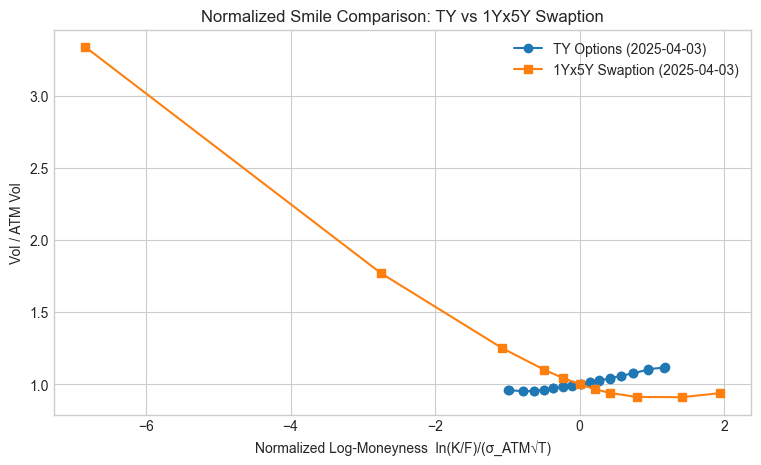


Q1c Comparison Summary:
          Product        Date  ATM Vol
0      TY Options  2025-04-03  0.06864
1  1Yx5Y Swaption  2025-04-03  0.33040


In [395]:
# Use the tariff shock day for comparison
cmp_date = nearest_date(m2025, '2025-04-03')

# TY smile
row_ty = m2025.loc[m2025['date'] == cmp_date].iloc[0]
smile_ty = build_ty_smile_from_row(row_ty)

norm_ty = normalize_smile(
    smile_ty['strike'],
    smile_ty['vol'],
    row_ty['Future Price'],
    row_ty['Expiration Option']
)

atm_ty = norm_ty['atm'].iloc[0]

# Swaption smile
swp_row = swaption_merged.loc[swaption_merged['date'] == cmp_date]

if swp_row.empty:
    cmp_date = nearest_date(swaption_merged, cmp_date)
    swp_row = swaption_merged.loc[swaption_merged['date'] == cmp_date]

swp_row = swp_row.iloc[0]

F_sw = float(swp_row['atm_fwd_pct'])

K_sw = np.array([
    float(swp_row[f'{c}_K']) for c in swaption_offsets
])

vol_sw = np.array([
    float(swp_row[f'{c}_vol']) for c in swaption_offsets
])

norm_sw = normalize_smile(
    K_sw,
    vol_sw,
    F_sw,
    T=1.0
)

atm_sw = norm_sw['atm'].iloc[0]


# Plot normalized smiles
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(
    norm_ty['x_norm'],
    norm_ty['vol_norm'],
    'o-',
    label=f'TY Options ({cmp_date.date()})'
)

ax.plot(
    norm_sw['x_norm'],
    norm_sw['vol_norm'],
    's-',
    label=f'1Yx5Y Swaption ({cmp_date.date()})'
)

ax.set_title("Normalized Smile Comparison: TY vs 1Yx5Y Swaption")
ax.set_xlabel("Normalized Log-Moneyness  ln(K/F)/(σ_ATM√T)")
ax.set_ylabel("Vol / ATM Vol")

ax.legend()

plt.show()

# Summary table
comparison_summary = pd.DataFrame({
    "Product": ["TY Options", "1Yx5Y Swaption"],
    "Date": [cmp_date.date(), cmp_date.date()],
    "ATM Vol": [atm_ty, atm_sw]
})

print("\nQ1c Comparison Summary:")
print(comparison_summary)

After normalization, the TY and swaption smiles display noticeably different shapes. The TY option smile has a mild positive normalized skew, producing a relatively smooth right wing in the normalized space.

The 1Yx5Y swaption smile, however, shows strong negative skew and a much more expensive left tail. Deep out-of-the-money receiver swaptions have normalized volatilities well above the ATM level, while high-strike payer swaptions remain closer to ATM volatility. In the normalized plot, the left tail reaches values above 3x ATM volatility, indicating substantial pricing of extreme downside rate scenarios.

These differences suggest that the swaption market embeds significantly stronger tail-risk asymmetry than the TY futures option market.


## Question 2: SABR Calibration

### Part 2(a): SABR calibration on Representative Date

The SABR model with $\beta = 0.5$ was calibrated to the TY option smile by minimizing the sum of squared volatility errors over the parameters $(\rho, \nu)$. 

At each step of the optimization, the parameter $\alpha$ was solved analytically from the ATM volatility constraint so that the model exactly matches the market ATM volatility. 


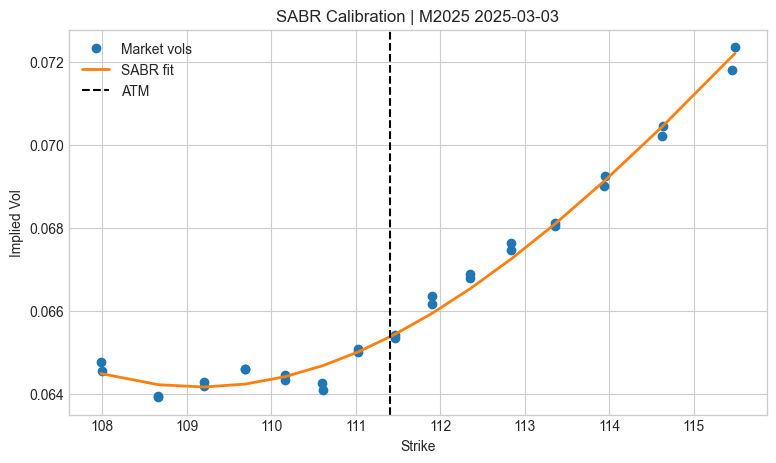

,Parameter,Value
0,alpha,0.677420
1,rho,0.250226
2,nu,1.039737
3,rmse,0.000250


In [396]:
# SABR calibration on representative date
beta = 0.5

res_rep = calibrate_sabr_atm_pinned(
    F=float(rep_row['Future Price']),
    T=float(rep_row['Expiration Option']),
    K=rep_smile['strike'].values,
    sigma_mkt=rep_smile['vol'].values,
    beta=beta
)

# Compute fitted vols
fit_rep = sabr_vol(
    float(rep_row['Future Price']),
    rep_smile['strike'].values,
    float(rep_row['Expiration Option']),
    res_rep['alpha'],
    beta,
    res_rep['rho'],
    res_rep['nu']
)

# Plot market vs SABR
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(rep_smile['strike'], rep_smile['vol'], 'o', label="Market vols")
ax.plot(rep_smile['strike'], fit_rep, '-', lw=2, label="SABR fit")

ax.axvline(rep_row['Future Price'], linestyle='--', color='black', label='ATM')

ax.set_title(f"SABR Calibration | M2025 {rep_date.date()}")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Vol")

ax.legend()

plt.show()

# Parameter table
pd.DataFrame({
    "Parameter": ["alpha","rho","nu","rmse"],
    "Value": [res_rep['alpha'],res_rep['rho'],res_rep['nu'],res_rep['rmse']]
})

The resulting fitted smile closely tracks the market smile across strikes, indicating that the SABR specification provides a good parametric representation of the observed volatility surface.

### Part 2(b): Daily Calibration Across All Contracts

In this section, the SABR model with $\beta = 0.5$ is calibrated to the TY option smile for every trading day in each available contract, similar to how it was done in part (a).

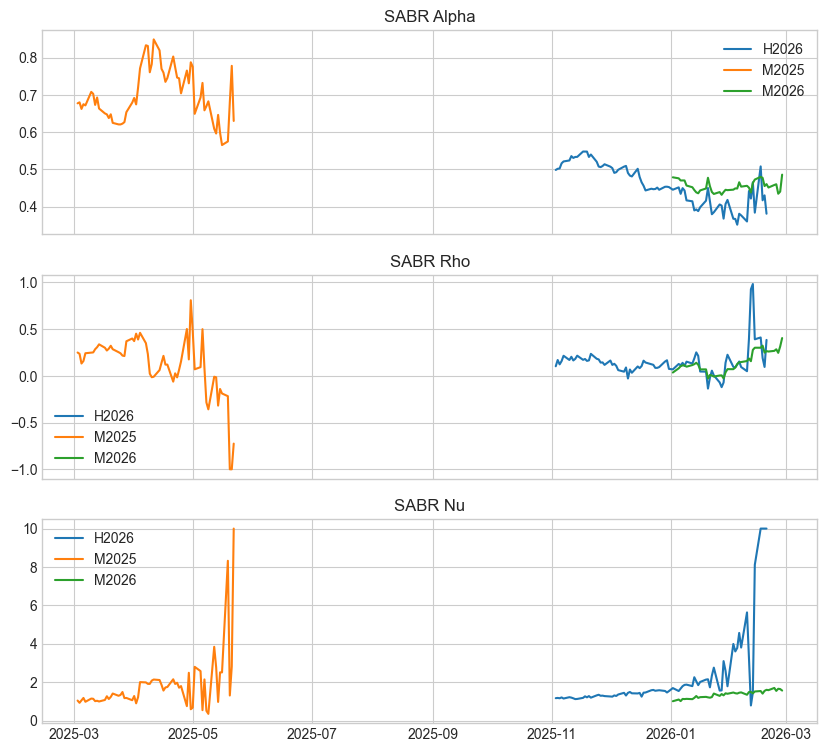

alpha                                                                      
         count      mean       std       min       25%       50%       75%       max
contract                                                                            
H2026     78.0  0.458067  0.054984  0.351974  0.415259  0.452430  0.507297  0.548204
M2025     59.0  0.698008  0.068444  0.565566  0.648626  0.680293  0.753182  0.848853
M2026     41.0  0.454905  0.014840  0.432155  0.443859  0.452432  0.465777  0.486208

rho                                                                      
         count      mean       std       min       25%       50%       75%       max
contract                                                                            
H2026     78.0  0.149734  0.163714 -0.135349  0.087143  0.128706  0.171776  0.983457
M2025     59.0  0.121627  0.324259 -0.998999  0.007603  0.212675  0.296496  0.809587
M2026     41.0  0.142609  0.111930 -0.028945  0.069898  0.119659  0.248990  0.404945

nu                                                                       
         count      mean       std       min       25%       50%       75%        max
contract                                                                             
H2026     78.0  2.285574  2.121726  0.784287  1.274812  1.535117  2.037665  10.000000
M2025     59.0  1.804335  1.557716  0.346361  1.055045  1.334657  2.039741  10.000000
M2026     41.0  1.358357  0.184475  1.005327  1.207205  1.402810  1.488259   1.697041

In [397]:
# Daily calibration across all TY contracts
calib_M2025 = calibrate_contract_daily(ty_contracts['M2025'], "M2025")
calib_H2026 = calibrate_contract_daily(ty_contracts['H2026'], "H2026")
calib_M2026 = calibrate_contract_daily(ty_contracts['M2026'], "M2026")

sabr_ts = pd.concat([calib_M2025, calib_H2026, calib_M2026])

# Plot Time Series
fig, axes = plt.subplots(3,1, figsize=(10,9), sharex=True)

for contract, df in sabr_ts.groupby("contract"):

    axes[0].plot(df['date'], df['alpha'], label=contract)
    axes[1].plot(df['date'], df['rho'], label=contract)
    axes[2].plot(df['date'], df['nu'], label=contract)

axes[0].set_title("SABR Alpha")
axes[1].set_title("SABR Rho")
axes[2].set_title("SABR Nu")

for ax in axes:
    ax.legend()

plt.show()

# Summary Statistics
summary_alpha = sabr_ts.groupby("contract")[["alpha"]].describe()
summary_rho = sabr_ts.groupby("contract")[["rho"]].describe()
summary_nu = sabr_ts.groupby("contract")[["nu"]].describe()

display(summary_alpha)
display(summary_rho)
display(summary_nu)

The calibrated SABR parameters display systematic differences across contracts. 

**Alpha $\alpha$:** 

The parameter $\alpha = \sigma_0$, which captures the intial volatility level on each day, is highest for the M2025 contract with an average value of approximately 0.70, compared to about 0.46 for both H2026 and M2026. This reflects the fact that M2025 is the nearest-to-expiry contract, and shorter-dated options typically have higher volatility levels.

M2025 also shows greater variability in $\alpha$ (standard deviation ≈ 0.068) relative to the longer-dated contracts. In contrast, M2026 displays the most stable  $\alpha$  dynamics, with a very small standard deviation of approximately 0.015, indicating that the volatility level of the longer-dated smile changes more gradually over time.

**Rho $\rho$:**

The parameter $\rho$ indicates the relationship between shocks to the future price and the implied volatility, controlling the skew of the volatility smile, determining whether implied volatility is higher for low strikes or high strikes.

Across all contracts, the mean value of $rho$ is positive, suggesting a mild right-skew in TY option smiles, consistent with the patterns observed earlier in Q1. However, the variability differs significantly across contracts.

The M2025 contract shows the largest fluctuations, with a standard deviation of 0.34 and extreme values reaching the optimization boundary ($\rho = -0.999$) close to expiration. By comparison, M2026 again has the greatest stability, with a much smaller standard deviation (0.11) and a narrower range of values.

**Nu $\nu$:**

The parameter $\nu$ indicates the curvature of the smile, capturing how steep the volatility wings become.

The mean value of $\nu$ ranges from approximately 1.36 for M2026 to 1.98 for H2026, indicating moderate curvature across contracts. However, significant volatiility and spikes are visible for both M2025 and H2026, where the parameter occasionally reaches the imposed upper bound of 10.0, close to expiration.

Overall, the SABR parameters for longer-dated contracts (particularly M2026) are substantially more stable over time, while the nearer-dated M2025 contract displays the greatest parameter variability.

### Part (c): Calibration RMSE 

We evaluate the quality of each SABR calibration by computing the root-mean-square error between the market implied volatilities and the SABR-fitted implied volatilities across all strikes for each trading day.

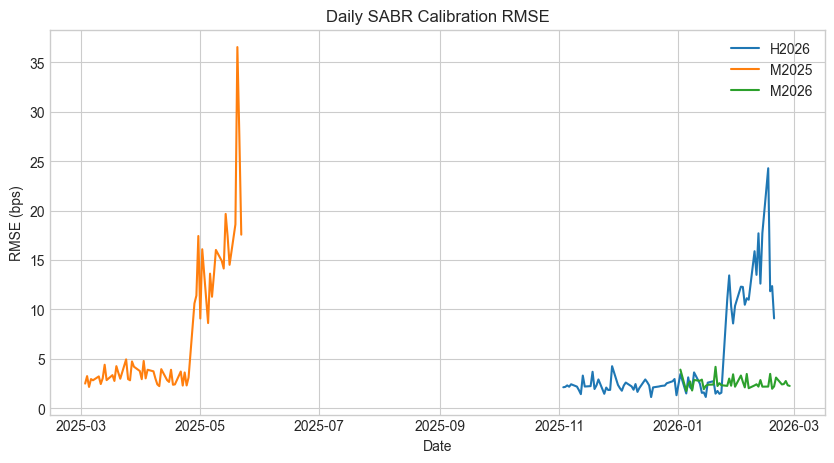

In [398]:
fig, ax = plt.subplots(figsize=(10,5))

for contract, df in sabr_ts.groupby("contract"):
    ax.plot(df['date'], df['rmse'] * 10000, label=contract)

ax.set_title("Daily SABR Calibration RMSE")
ax.set_ylabel("RMSE (bps)")
ax.set_xlabel("Date")

ax.legend()

plt.show()

In [399]:
worst = sabr_ts.sort_values("rmse", ascending=False).head(10)

print("Worst calibration dates:")
print(worst[['contract','date','rmse']])

Worst calibration dates:
   contract       date      rmse
56    M2025 2025-05-20  0.003655
57    M2025 2025-05-21  0.002765
74    H2026 2026-02-16  0.002429
52    M2025 2025-05-14  0.001967
55    M2025 2025-05-19  0.001861
73    H2026 2026-02-13  0.001772
71    H2026 2026-02-11  0.001770
58    M2025 2025-05-22  0.001757
42    M2025 2025-04-30  0.001743
53    M2025 2025-05-15  0.001740


Overall, the SABR model fits the TY option smiles very well, with RMSE values typically below 0.0015, indicating that the parametric SABR specification is able to closely replicate the observed implied volatility surface across strikes.

However, the plot reveals several periods where the calibration error increases noticeably.

The largest RMSE values occur for the M2025 contract during May 2025, with the worst fit occurring on May 20, 2025 (RMSE ≈ 0.0037). This cluster of higher errors appears near the end of the M2025 contract's life, where option maturities are short and the volatility smile becomes more irregular. 

Similarly, the H2026 contract shows a spike in RMSE during February 2026, with the worst fit around February 16, 2026. This again corresponds to a period approaching contract expiration, where the smile tends to become more unstable and the SABR parameters may reach their imposed bounds.

In contrast, the M2026 contract exhibits consistently low RMSE values, indicating that the SABR model provides a stable and accurate representation of the volatility smile for longer-dated options.


# Question 3: Calibration Quality and Regime Identification

### Part 3(a): Daily RMSE vs ATM Volatility

Below we plot the time series of the daily fit RMSEs with ATM vols per contract, as well as a scatter plot comparing the two. 


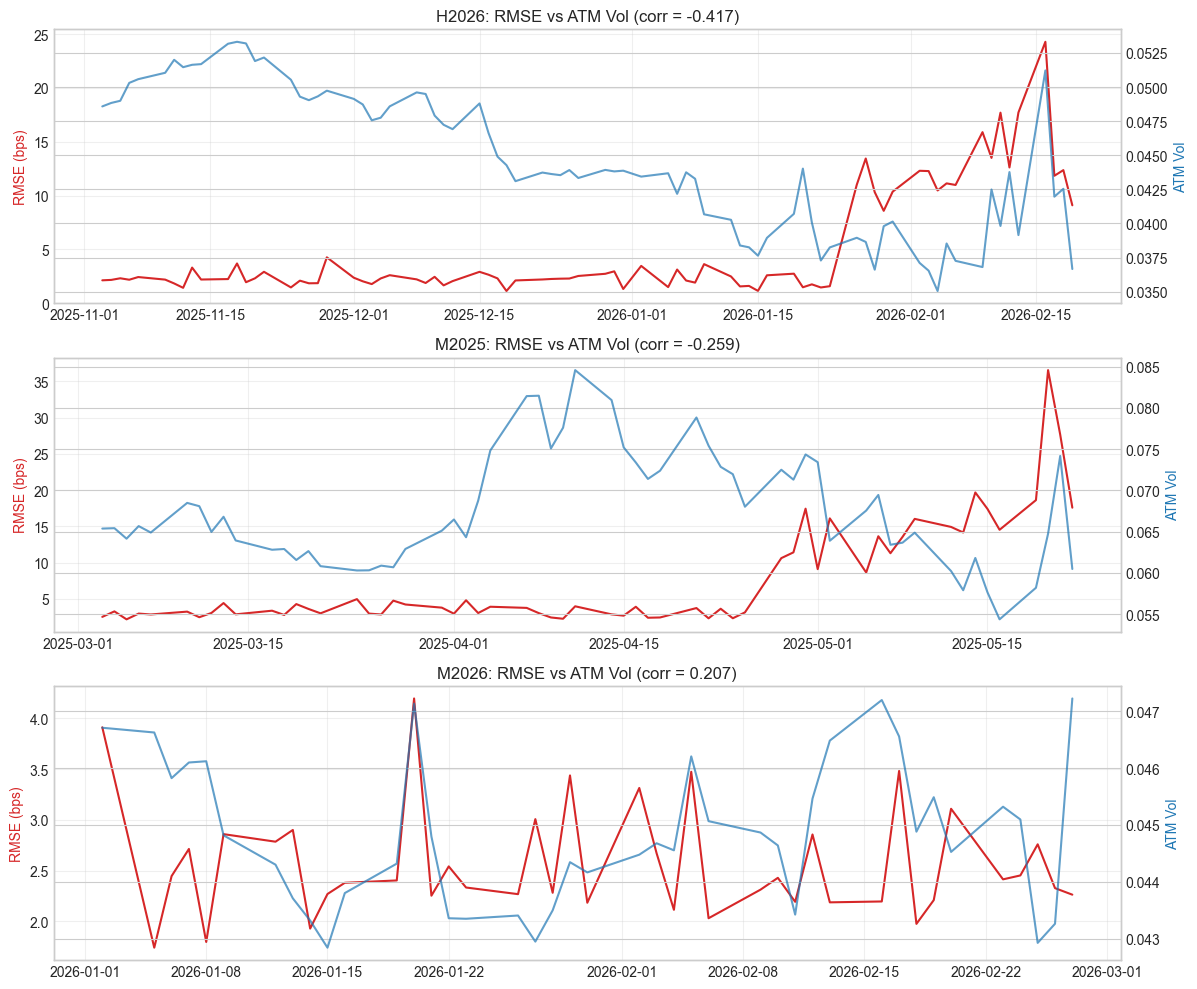


Correlation between RMSE and ATM Vol:
contract
H2026   -0.4166
M2025   -0.2594
M2026    0.2073
Name: RMSE vs ATM Vol Correlation, dtype: float64


In [400]:
# RMSE vs ATM vol relationship
fig, axes = plt.subplots(3, 1, figsize=(12,10), sharex=False)

contracts = sorted(sabr_ts['contract'].unique())

for i, contract in enumerate(contracts):

    df = sabr_ts[sabr_ts['contract'] == contract].sort_values('date')

    ax = axes[i]
    ax2 = ax.twinx()

    # RMSE
    ax.plot(df['date'], df['rmse'] * 10000, color='tab:red', linewidth=1.5, label='RMSE')

    # ATM vol
    ax2.plot(df['date'], df['atm_vol'], color='tab:blue', linewidth=1.5, alpha=0.7, label='ATM Vol')

    # correlation
    corr = df[['rmse','atm_vol']].corr().iloc[0,1]

    ax.set_title(f"{contract}: RMSE vs ATM Vol (corr = {corr:.3f})")

    ax.set_ylabel("RMSE (bps)", color='tab:red')
    ax2.set_ylabel("ATM Vol", color='tab:blue')

    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation table
corr_table = (
    sabr_ts
    .groupby('contract')
    .apply(lambda x: x[['rmse','atm_vol']].corr().iloc[0,1])
    .rename("RMSE vs ATM Vol Correlation")
)

print("\nCorrelation between RMSE and ATM Vol:")
print(corr_table.round(4))

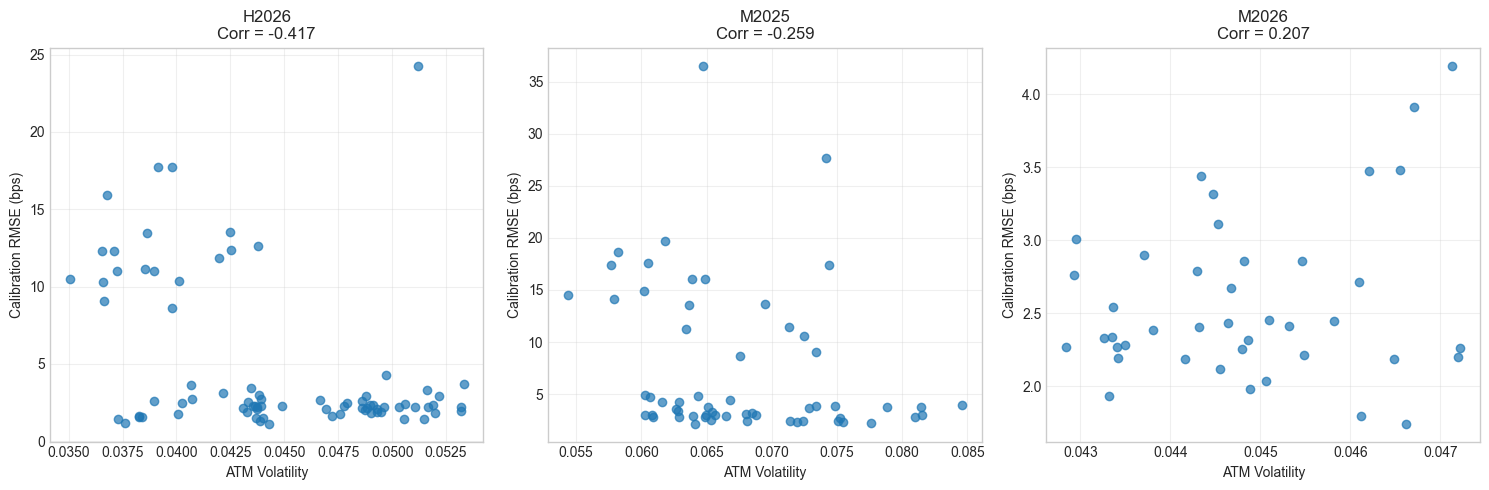

In [401]:
# Scatter: RMSE vs ATM Volatility
fig, axes = plt.subplots(1, 3, figsize=(15,5))

contracts = sorted(sabr_ts['contract'].unique())

for i, contract in enumerate(contracts):

    df = sabr_ts[sabr_ts['contract'] == contract]

    ax = axes[i]

    ax.scatter(
        df['atm_vol'],
        df['rmse'] * 10000,
        alpha=0.7
    )

    corr = df[['rmse','atm_vol']].corr().iloc[0,1]

    ax.set_title(f"{contract}\nCorr = {corr:.3f}")
    ax.set_xlabel("ATM Volatility")
    ax.set_ylabel("Calibration RMSE (bps)")

    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

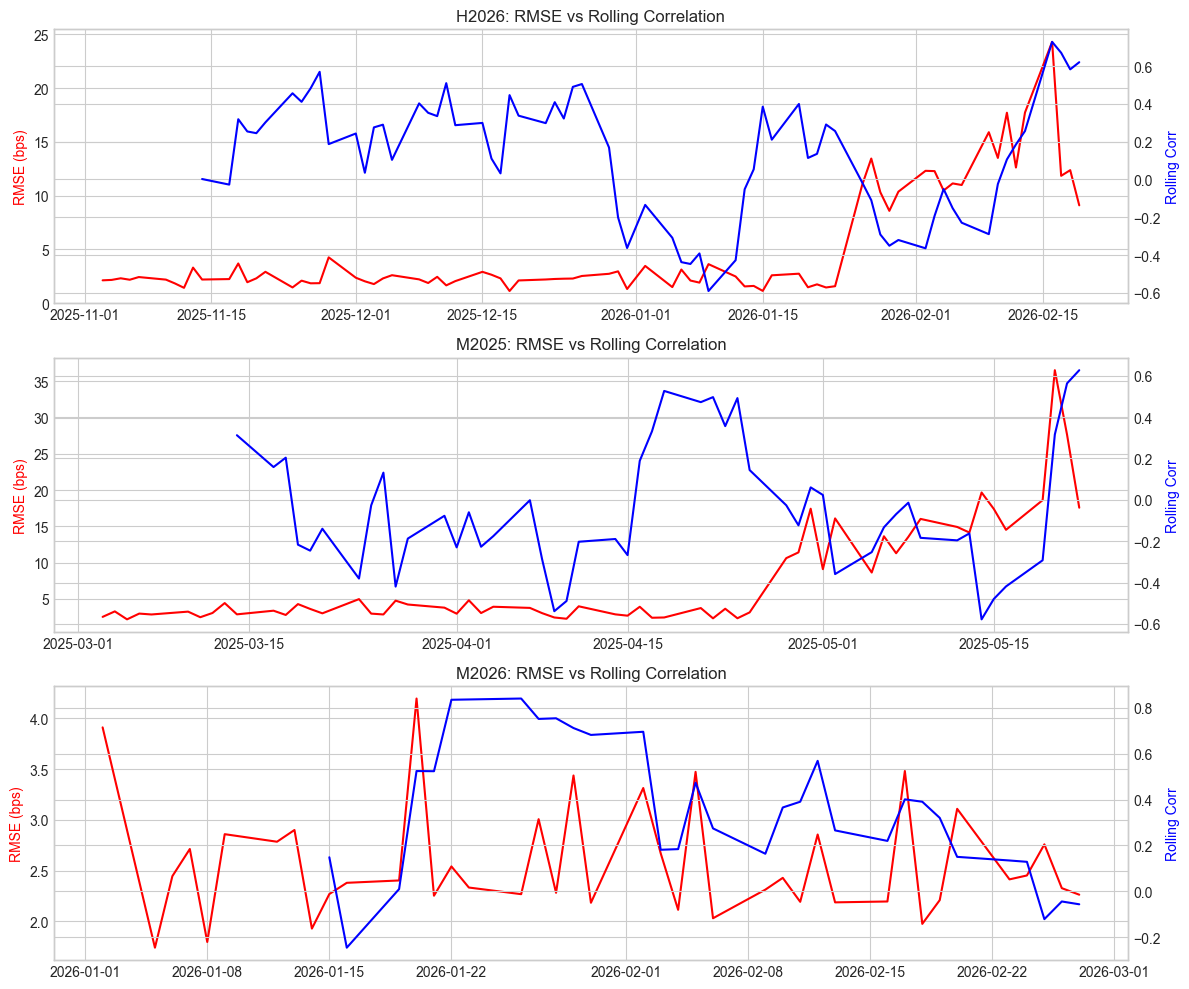

In [402]:
fig, axes = plt.subplots(3,1, figsize=(12,10))

for i, contract in enumerate(contracts):

    df = sabr_ts[sabr_ts['contract']==contract].sort_values("date").copy()

    df['rolling_corr'] = df['rmse'].rolling(10).corr(df['atm_vol'])

    ax = axes[i]
    ax2 = ax.twinx()

    ax.plot(df['date'], df['rmse'] * 10000, color="red", label="RMSE")
    ax2.plot(df['date'], df['rolling_corr'], color="blue", label="Rolling Corr")

    ax.set_ylabel("RMSE (bps)", color="red")
    ax2.set_ylabel("Rolling Corr", color="blue")

    ax.set_title(f"{contract}: RMSE vs Rolling Correlation")

plt.tight_layout()
plt.show()

Across the three contracts, the relationship between RMSE and ATM volatility appears weak and inconsistent. 

At the contract level, the correlations vary in sign. For H2026 (-0.417) and M2025 (-0.259), higher ATM volatility is associated with slightly lower RMSE, suggesting that SABR fits somewhat better during more volatile periods. In contrast, M2026 (+0.207) shows a weak positive relationship. Because the direction and magnitude of these correlations differ across contracts, there is no stable monotonic relationship between volatility levels and SABR fit quality.

The scatter plots reinforce this conclusion: observations are broadly dispersed without a clear linear pattern. Rolling correlations between RMSE and ATM volatility show that the relationship is unstable over time, fluctuating between positive and negative values.

Close to option expiration, particularly for the H2026 and M2025 contracts, the correlation becomes stronger and positive. This reflects the fact that volatility smiles become more irregular and harder to fit when time to maturity is short.

### Part (b): Day-Over-Day Parameter Change

We identify regime shifts in the volatility smile by ranking days according to the magnitude of SABR parameter changes, measured as $|z_{\alpha}| + |z_{\nu}| + |z_{\rho}|$. Each parameter change is standardized by its own historical volatility. This normalization is necessary because the SABR parameters operate on different numerical scales.

In [403]:
# Identify largest SABR parameter jumps

chg = sabr_ts.copy().sort_values(['contract','date'])

# Daily changes
chg['d_alpha'] = chg.groupby('contract')['alpha'].diff()
chg['d_nu'] = chg.groupby('contract')['nu'].diff()
chg['d_rho'] = chg.groupby('contract')['rho'].diff()

# Standardize each parameter by its contract-level volatility
chg['z_alpha'] = chg['d_alpha'] / chg.groupby('contract')['d_alpha'].transform('std')
chg['z_nu'] = chg['d_nu'] / chg.groupby('contract')['d_nu'].transform('std')
chg['z_rho'] = chg['d_rho'] / chg.groupby('contract')['d_rho'].transform('std')

# Jump score
chg['jump_score'] = chg[['z_alpha','z_nu','z_rho']].abs().sum(axis=1)

# Percent contribution of each parameter
chg['pct_alpha (%)'] = abs(chg['z_alpha']) / chg['jump_score']
chg['pct_nu (%)'] = abs(chg['z_nu']) / chg['jump_score']
chg['pct_rho (%)'] = abs(chg['z_rho']) / chg['jump_score']

# Convert to %
chg[['pct_alpha (%)','pct_nu (%)','pct_rho (%)']] *= 100

# Convert RMSE to volatility basis points
chg['rmse_bps'] = chg['rmse'] * 10000

# Top events
top10_z = (
    chg.dropna(subset=['jump_score'])
       .sort_values('jump_score', ascending=False)
       .head(10)
)

print("Top standardized jumps with contribution breakdown:")
display(
    top10_z[
        ['contract','date','jump_score',
         'pct_alpha (%)','pct_nu (%)','pct_rho (%)', 'rmse_bps']
    ].round(2)
)

Top standardized jumps with contribution breakdown:


,contract,date,jump_score,pct_alpha (%),pct_nu (%),pct_rho (%),rmse_bps
73,H2026,2026-02-13,14.41,20.30,46.56,33.13,17.72
56,M2025,2025-05-20,9.95,22.73,39.91,37.36,36.55
58,M2025,2025-05-22,8.55,37.21,47.52,15.27,17.57
70,H2026,2026-02-10,8.12,36.18,29.41,34.41,13.50
71,H2026,2026-02-11,7.51,9.68,33.34,56.97,17.70
40,M2026,2026-02-27,6.60,51.34,14.08,34.57,2.26
74,H2026,2026-02-16,6.53,68.39,29.18,2.43,24.29
44,M2025,2025-05-02,5.85,46.37,20.56,33.07,16.09
29,M2026,2026-02-12,5.84,32.46,15.02,52.52,2.86
42,M2025,2025-04-30,5.30,22.92,20.29,56.79,17.43


The largest parameter jumps occur primarily in contracts approaching expiration, particularly in the M2025 sample during May 2025 and the H2026 sample in February 2026. These periods correspond to increased smile instability as time-to-maturity declines.

Examining the parameter contribution breakdown shows that the largest jumps are primarily driven by changes in $\nu$ and $\rho$ rather than $\alpha$. The contribution table confirms that many of the largest events are dominated by $\nu$ and $\rho$  changes, indicating that these days correspond to shape adjustments in the smile rather than simple parallel shifts in volatility levels.


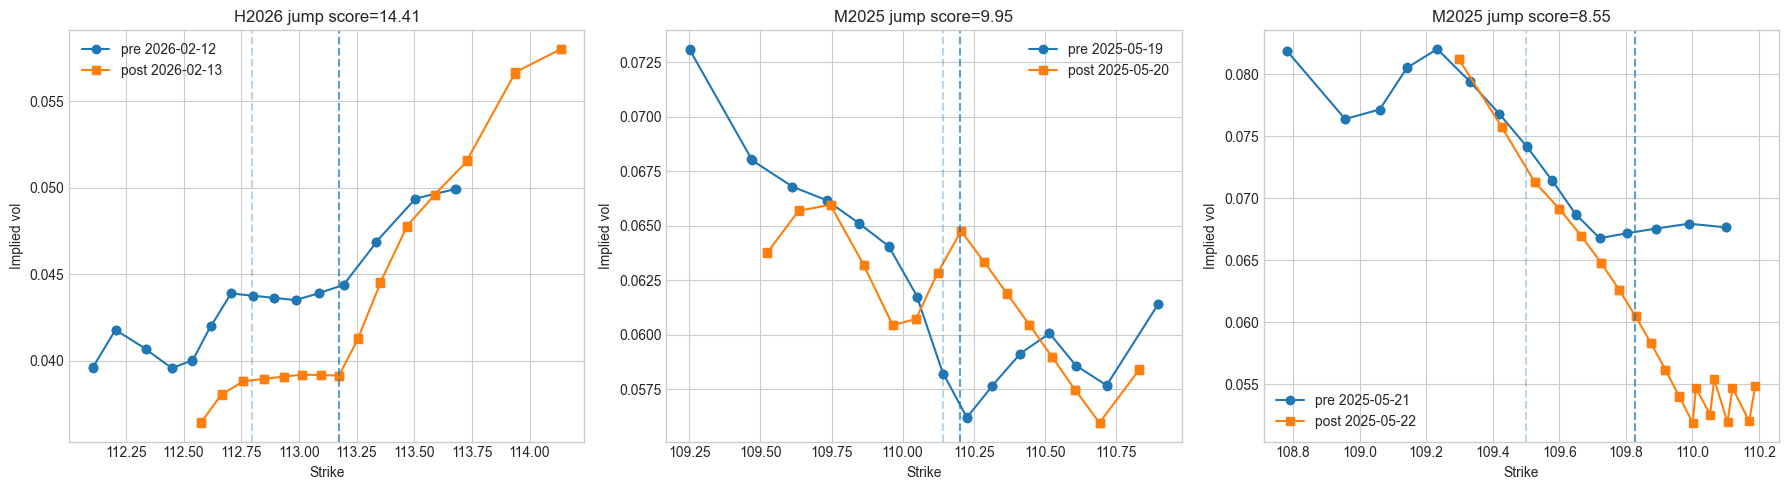

In [404]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

for ax, (_, ev) in zip(axes, top10_z.head(3).iterrows()):

    c = ev['contract']
    d1 = pd.Timestamp(ev['date'])

    hist = chg[chg['contract']==c].sort_values('date')
    d0 = hist[hist['date'] < d1]['date'].max()

    r0 = ty_contracts[c].loc[ty_contracts[c]['date']==d0].iloc[0]
    r1 = ty_contracts[c].loc[ty_contracts[c]['date']==d1].iloc[0]

    s0 = build_ty_smile_from_row(r0)
    s1 = build_ty_smile_from_row(r1)

    ax.plot(s0['strike'], s0['vol'], 'o-', label=f'pre {d0.date()}')
    ax.plot(s1['strike'], s1['vol'], 's-', label=f'post {d1.date()}')

    ax.axvline(r0['Future Price'], ls='--', alpha=0.3)
    ax.axvline(r1['Future Price'], ls='--', alpha=0.7)

    ax.set_title(f"{c} jump score={ev['jump_score']:.2f}")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Implied vol")
    ax.legend()

plt.tight_layout()
plt.show()

The pre- and post-day smiles illustrate these shape changes clearly:

**H2026 (Feb 12 → Feb 13, 2026):**
The right wing of the smile steepens significantly while the left wing shifts downward. This corresponds to a large increase in curvature and skew, consistent with the large $\nu$ contribution in the jump score.

**M2025 (May 19 → May 20, 2025):**
The smile displays an unusual local hump near the ATM region. While most strikes shift downward relative to the previous day, the ATM volatility remains comparatively elevated. This distortion likely reflects microstructure effects close to expiration, where strong demand for ATM optionality can keep ATM implied volatility elevated relative to neighboring strikes.

**M2025 (May 21 → May 22, 2025):**
The right tail becomes substantially cheaper relative to ATM, indicating a sharp change in skew.

Overall, the largest events in the ranking correspond to days when the shape of the smile moved unusually relative to its historical behavior. These regime shifts are primarily driven by changes in curvature and skew, rather than simple changes in the level of volatility.

In [405]:
# Shape metrics
chg['jump_raw'] = abs(chg['z_nu']) + abs(chg['z_rho'])

# Rankings
top10_raw = (
    chg.dropna(subset=['jump_raw'])
       .sort_values('jump_raw', ascending=False)
       .head(10)
)

top30_raw = (
    chg.dropna(subset=['jump_raw'])
       .sort_values('jump_raw', ascending=False)
       .head(30)
)

top30_z = (
    chg.dropna(subset=['jump_score'])
       .sort_values('jump_score', ascending=False)
       .head(30)
)

# Event identifiers
top10_z_ids = set(zip(top10_z['contract'], top10_z['date']))
top10_raw_ids = set(zip(top10_raw['contract'], top10_raw['date']))

top30_z_ids = set(zip(top30_z['contract'], top30_z['date']))
top30_raw_ids = set(zip(top30_raw['contract'], top30_raw['date']))

# overlap
overlap10 = len(top10_z_ids & top10_raw_ids)
overlap30 = len(top30_z_ids & top30_raw_ids)

print("Top-10 overlap percentage:", round(100*overlap10/10,2), "%")
print("Top-30 overlap percentage:", round(100*overlap30/30,2), "%")

Top-10 overlap percentage: 70.0 %
Top-30 overlap percentage: 83.33 %


Comparing the standardized ranking with changes in alpha with ranking based on just nu and rho shows strong agreement, with 70% overlap in the top 10 events and over 80% overlap in the top 30. This indicates that the largest smile regime shifts are primarily driven by changes in skew and curvature, rather than simple level adjustments captured by $\alpha$.


### Part (c): H2026 vs M2026 Parameters

To study whether smile shape depends on option maturity, we compare SABR parameters for the H2026 and M2026 contracts during the January–February 2026 window when both contracts trade simultaneously. 

For each common trading date, we align the calibrated parameters and plot their time series.

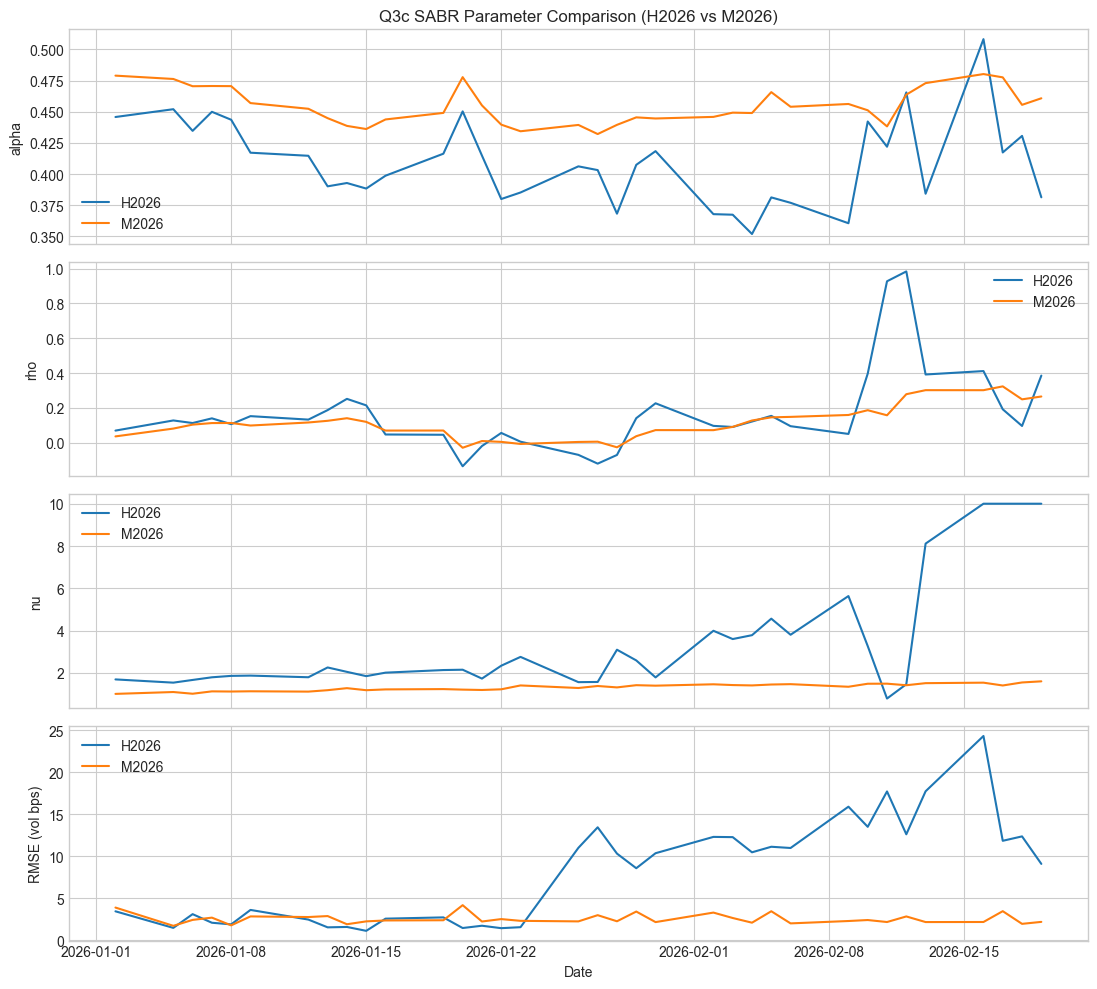

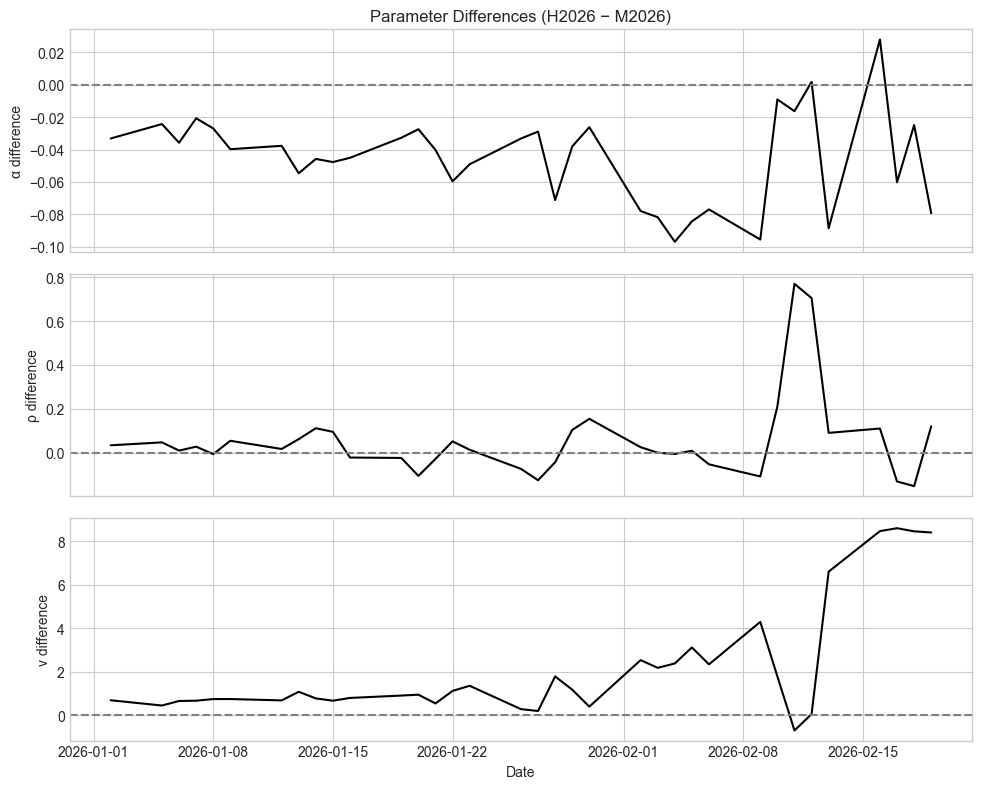

Parameter correlation matrix:


,alpha_H2026,alpha_M2026,rho_H2026,rho_M2026,nu_H2026,nu_M2026
alpha_H2026,1.000,0.577,0.308,0.222,-0.016,-0.217
alpha_M2026,0.577,1.000,0.108,0.435,0.373,-0.165
rho_H2026,0.308,0.108,1.000,0.646,0.106,0.380
rho_M2026,0.222,0.435,0.646,1.000,0.717,0.501
nu_H2026,-0.016,0.373,0.106,0.717,1.000,0.633
nu_M2026,-0.217,-0.165,0.380,0.501,0.633,1.000


Summary statistics across overlap window:


,mean,std
alpha_H2026,0.4096,0.0343
alpha_M2026,0.4548,0.0145
rho_H2026,0.1712,0.2372
rho_M2026,0.1162,0.0966
nu_H2026,3.4587,2.7567
nu_M2026,1.3147,0.1616


In [406]:

# H2026 vs M2026 parameter comparison during overlap window
overlap_start = pd.Timestamp('2026-01-01')
overlap_end = pd.Timestamp('2026-02-28')

h = sabr_ts[(sabr_ts['contract'] == 'H2026') & 
            (sabr_ts['date'].between(overlap_start, overlap_end))]

m = sabr_ts[(sabr_ts['contract'] == 'M2026') & 
            (sabr_ts['date'].between(overlap_start, overlap_end))]

ov = h[['date','alpha','rho','nu','rmse']].merge(
    m[['date','alpha','rho','nu','rmse']],
    on='date',
    suffixes=('_H2026','_M2026')
)

# Convert RMSE to vol bps
ov['rmse_H2026_bps'] = ov['rmse_H2026'] * 10000
ov['rmse_M2026_bps'] = ov['rmse_M2026'] * 10000

# Parameter difference columns
ov['alpha_diff'] = ov['alpha_H2026'] - ov['alpha_M2026']
ov['rho_diff'] = ov['rho_H2026'] - ov['rho_M2026']
ov['nu_diff'] = ov['nu_H2026'] - ov['nu_M2026']

fig, axes = plt.subplots(4,1, figsize=(11,10), sharex=True)

# alpha
axes[0].plot(ov['date'], ov['alpha_H2026'], label='H2026')
axes[0].plot(ov['date'], ov['alpha_M2026'], label='M2026')
axes[0].set_ylabel('alpha')
axes[0].legend()

# rho
axes[1].plot(ov['date'], ov['rho_H2026'], label='H2026')
axes[1].plot(ov['date'], ov['rho_M2026'], label='M2026')
axes[1].set_ylabel('rho')
axes[1].legend()

# nu
axes[2].plot(ov['date'], ov['nu_H2026'], label='H2026')
axes[2].plot(ov['date'], ov['nu_M2026'], label='M2026')
axes[2].set_ylabel('nu')
axes[2].legend()

# RMSE
axes[3].plot(ov['date'], ov['rmse_H2026_bps'], label='H2026')
axes[3].plot(ov['date'], ov['rmse_M2026_bps'], label='M2026')
axes[3].set_ylabel('RMSE (vol bps)')
axes[3].set_xlabel('Date')
axes[3].legend()

axes[0].set_title('Q3c SABR Parameter Comparison (H2026 vs M2026)')

plt.tight_layout()
plt.show()

# Plot Difference

fig, axes = plt.subplots(3,1, figsize=(10,8), sharex=True)

# alpha difference
axes[0].plot(ov['date'], ov['alpha_diff'], color='black')
axes[0].axhline(0, linestyle='--', color='gray')
axes[0].set_ylabel('α difference')
axes[0].set_title('Parameter Differences (H2026 − M2026)')

# rho difference
axes[1].plot(ov['date'], ov['rho_diff'], color='black')
axes[1].axhline(0, linestyle='--', color='gray')
axes[1].set_ylabel('ρ difference')

# nu difference
axes[2].plot(ov['date'], ov['nu_diff'], color='black')
axes[2].axhline(0, linestyle='--', color='gray')
axes[2].set_ylabel('ν difference')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

# Correlation table
corr_table = ov[[
    'alpha_H2026','alpha_M2026',
    'rho_H2026','rho_M2026',
    'nu_H2026','nu_M2026'
]].corr()

print("Parameter correlation matrix:")
display(corr_table.round(3))

# Summary Stats
summary_stats = ov[[
    'alpha_H2026','alpha_M2026',
    'rho_H2026','rho_M2026',
    'nu_H2026','nu_M2026'
]].agg(['mean','std']).T

summary_stats.columns = ['mean','std']

print("Summary statistics across overlap window:")
display(summary_stats.round(4))

First, the $\alpha$ parameter is generally lower for H2026 than for M2026 early in the sample, although the two series remain moderately correlated (correlation ≈ 0.58). This suggests that both contracts respond to similar underlying volatility conditions in the Treasury market, but the longer-dated contract maintains a slightly higher overall volatility level.

$\rho$ is similar across contracts but tends to be more volatile for the shorter-dated H2026 contract. The average value of $\rho$ is 0.1712 for H2026 versus 0.1162 for M2026, and the standard deviation is also much larger for H2026 (0.237 vs 0.097). The correlation between the two $\rho$ series is relatively high (≈ 0.65), indicating that the direction of skew movements is largely shared across maturities. However, the larger fluctuations in H2026 reflect the greater sensitivity of short-dated options to short-term market flows and positioning.

The most noticeable difference appears in the $\nu$ parameter. Over the overlap window, $\nu$ averages 3.46 for H2026 compared with 1.31 for M2026, and its dispersion is much larger for the shorter-dated contract (std ≈ 2.76 vs 0.16). While remains relatively stable for M2026, the H2026 contract experiences sharp increases during February, eventually hitting the upper calibration bound. This behavior indicates that curvature changes in the volatility smile are significantly stronger for the shorter-dated options, especially as expiration approaches.

Overall, the comparison shows that smile shape does depend on option expiry. On the same calendar dates, the shorter-dated H2026 contract have stronger curvature and more unstable skew, while the longer-dated M2026 contract maintains a smoother and more stable smile with a slightly higher overall volatility level. This pattern is consistent with option market dynamics, where near-expiry options are more sensitive to short-term uncertainty and hedging demand, which tends to amplify skew and curvature, whereas longer-dated options reflect smoother expectations about longer-horizon volatility.

### Part (d): Lazy Recalibration 

To evaluate how quickly SABR parameters need to be updated, we perform a “lazy recalibration” experiment. Instead of recalibrating all parameters daily, we hold the smile shape parameters $\rho$ and $\nu$ fixed at their values from $N$ days earlier (for $N \in \{5, 10, 20\}$), while updating only $\alpha$ each day using the ATM volatility constraint. 

This experiment effectively tests whether the shape of the volatility smile evolves more slowly than the overall volatility level. 


In [407]:
# Lazy recalibration experiment
def lazy_rmse_for_contract(contract, N_list=(5,10,20), beta=0.5):

    df = ty_contracts[contract].sort_values('date').reset_index(drop=True)
    full = sabr_ts[sabr_ts['contract']==contract].sort_values('date').reset_index(drop=True)

    out_rows = []

    for N in N_list:

        rmses = []

        for i in range(N, len(df)):

            row = df.iloc[i]
            stale = full.iloc[i-N]

            if not np.isfinite(stale['rho']) or not np.isfinite(stale['nu']):
                continue

            smile = build_ty_smile_from_row(row)

            F = float(row['Future Price'])
            T = float(row['Expiration Option'])

            rho_stale = float(stale['rho'])
            nu_stale = float(stale['nu'])

            sigma_atm = float((row['P50dvol'] + row['C50dvol'])/2)

            alpha = solve_alpha_from_atm(F, T, beta, rho_stale, nu_stale, sigma_atm)

            if not np.isfinite(alpha):
                continue

            fit = sabr_vol(
                F,
                smile['strike'].values,
                T,
                alpha,
                beta,
                rho_stale,
                nu_stale
            )

            rmse = np.sqrt(np.mean((fit - smile['vol'].values)**2))

            rmses.append(rmse)

        out_rows.append({
            'contract': contract,
            'N': N,
            'rmse_lazy_mean_bps': np.mean(rmses)*10000,
            'rmse_lazy_median_bps': np.median(rmses)*10000
        })

    base = full['rmse'].mean()*10000

    out = pd.DataFrame(out_rows)

    out['rmse_full_mean_bps'] = base
    out['degradation_pct'] = 100*(out['rmse_lazy_mean_bps']/base - 1)

    return out

# Run Lazy Calibration
lazy_tables = [
    lazy_rmse_for_contract(
        c,
        N_list=range(1,21)   # days 1 through 20
    )
    for c in CONTRACT_SHEETS.keys()
]

lazy_summary = pd.concat(lazy_tables, ignore_index=True)

display(lazy_summary.round(2).head())


,contract,N,rmse_lazy_mean_bps,rmse_lazy_median_bps,rmse_full_mean_bps,degradation_pct
0,M2025,1,15.49,9.88,7.43,108.51
1,M2025,2,18.55,12.86,7.43,149.80
2,M2025,3,19.89,15.08,7.43,167.85
3,M2025,4,21.91,16.23,7.43,194.97
4,M2025,5,22.52,17.95,7.43,203.25


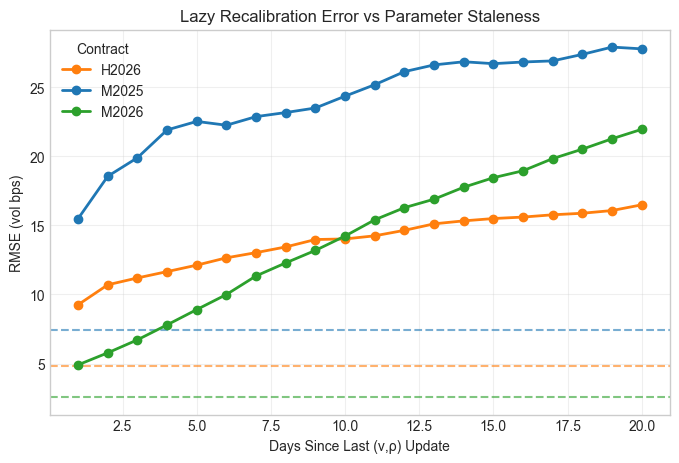

In [408]:
# Visualize lazy recalibration degradation
fig, ax = plt.subplots(figsize=(8,5))

# consistent colors
colors = dict(zip(sabr_ts["contract"].unique(), plt.cm.tab10.colors))

for contract, df in lazy_summary.groupby("contract"):

    color = colors[contract]

    # Lazy RMSE curve
    ax.plot(
        df["N"],
        df["rmse_lazy_mean_bps"],
        marker='o',
        linewidth=2,
        color=color,
        label=contract
    )

    # Baseline full RMSE (no legend entry)
    baseline = sabr_ts[sabr_ts["contract"]==contract]["rmse"].mean()*10000

    ax.axhline(
        baseline,
        linestyle="--",
        color=color,
        alpha=0.6
    )

ax.set_title("Lazy Recalibration Error vs Parameter Staleness")
ax.set_xlabel("Days Since Last (ν,ρ) Update")
ax.set_ylabel("RMSE (vol bps)")

ax.legend(title="Contract")
ax.grid(alpha=0.3)

plt.show()

For each day and each staleness horizon $N$, the SABR model is evaluated using parameters $\rho$ and $\nu$ from $N$ days earlier while recalibrating $\alpha$ using the ATM volatility constraint. The RMSE is then computed across the strikes in the option smile for that day by comparing the SABR-implied volatilities to the observed market implied volatilities. For each value of $N$, the reported RMSE is the average across all days in the sample, expressed in volatility basis points. 

The dashed lines indicate the average RMSE of the full daily SABR calibration for each contract, providing a baseline benchmark against which the lazy recalibration error can be compared.

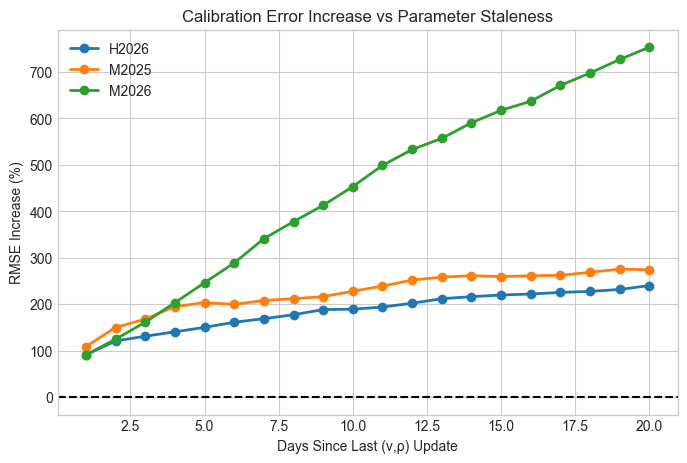

In [409]:
# Plot percentage degradation instead of raw RMSE
fig, ax = plt.subplots(figsize=(8,5))

for contract, df in lazy_summary.groupby("contract"):

    ax.plot(
        df["N"],
        df["degradation_pct"],
        marker='o',
        linewidth=2,
        label=contract
    )

ax.axhline(0, linestyle="--", color="black")

ax.set_title("Calibration Error Increase vs Parameter Staleness")
ax.set_xlabel("Days Since Last (ν,ρ) Update")
ax.set_ylabel("RMSE Increase (%)")

ax.legend()

plt.show()

The results show a clear monotonic relationship between parameter staleness and calibration error. As the parameters become older, the SABR fit gradually deteriorates across all contracts. However, the deterioration is relatively smooth rather than abrupt, indicating that the shape of the volatility smile evolves slowly over time.

In absolute terms of volatility basis points, the degradation is most pronounced for the M2026 contract, where RMSE rises from roughly 5 vol bps to over 22 vol bps when the shape parameters are held fixed for 20 days. M2025 and H2026 also show steady increases in RMSE as the parameters become stale, though the magnitude of the deterioration differs across contracts.

The second figure presents the same results in percentage terms relative to the baseline full calibration error. Here, although M2026 begins with a smaller baseline RMSE, the error grows rapidly as parameters become stale.

The lazy recalibration exercise highlights how sensitive smile fitting is to outdated shape parameters. In practice, recalibrating every few days may be acceptable in calmer markets, but weekly-or-longer gaps are too coarse, even for longer-dated contracts.

___
## Question 4: Listed vs OTC - Cross-Product Comparison

Using the April 2025 overlap between TY options and 1Yx5Y swaptions:

a) Calibrate SABR ($\beta=0.5$) to swaption smiles daily in April and plot $(\alpha,\nu,\rho)$ for both products.

b) On TY's largest day-over-day jump dates (Q3b), compare swaption parameter changes and whether $\nu,\rho$ move in the same direction/magnitude.

c) Normalize each product smile by ATM vol and overlay.

d) Add interpretation of why differences may exist.


### 4a) Swaption daily SABR calibration (April 2025)

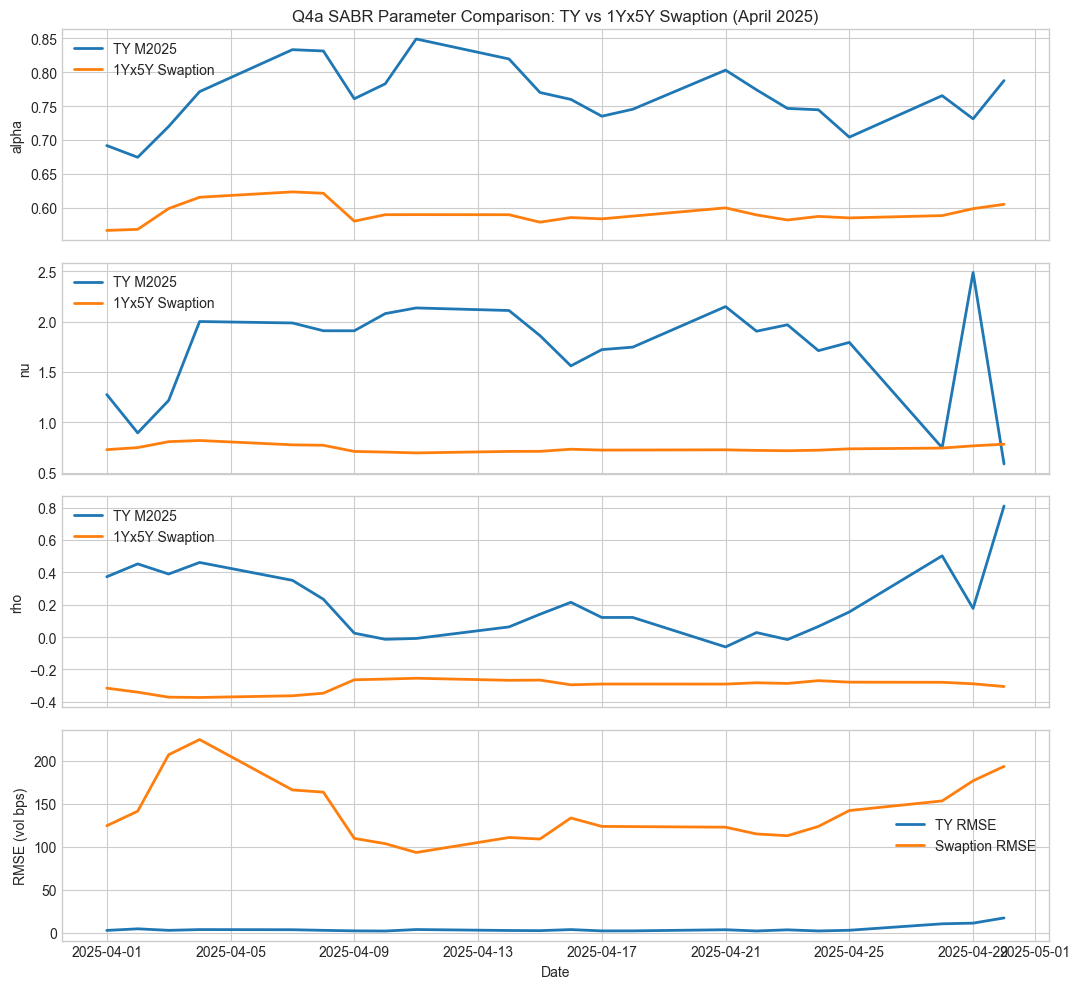

In [410]:
# Q4a: Swaption daily SABR calibration (April 2025)

swp = swaption_merged.copy()
# Restrict to April
swp_apr = (
    swp[swp['date'].between('2025-04-01','2025-04-30')]
    .sort_values('date')
    .reset_index(drop=True)
)
rows = []
prev_init = None

for _, r in swp_apr.iterrows():
    F = float(r['atm_fwd_pct'])          # forward swap rate
    T = 1.0                               # 1Y expiry for 1Yx5Y swaptions
    K = np.array([float(r[f'{c}_K']) for c in swaption_offsets])
    vol = np.array([float(r[f'{c}_vol']) for c in swaption_offsets])
    res = calibrate_sabr_atm_pinned(
        F=F,
        T=T,
        K=K,
        sigma_mkt=vol,
        beta=0.5,
        init=prev_init
    )
    if np.isfinite(res['rho']) and np.isfinite(res['nu']):
        prev_init = [res['rho'], res['nu']]
    rows.append({
        "date": r["date"],
        "alpha": res["alpha"],
        "rho": res["rho"],
        "nu": res["nu"],
        "rmse_bps": res["rmse"] * 10000
    })
swp_calib = pd.DataFrame(rows)

# TY comparison sample (M2025 contract)
ty_apr = (
    sabr_ts[
        (sabr_ts["contract"]=="M2025") &
        (sabr_ts["date"].between("2025-04-01","2025-04-30"))
    ]
    .sort_values("date")
)

# Plot parameter comparison
fig, axes = plt.subplots(4,1, figsize=(11,10), sharex=True)
for ax, p in zip(axes[:3], ["alpha","nu","rho"]):
    ax.plot(
        ty_apr["date"],
        ty_apr[p],
        label="TY M2025",
        linewidth=2
    )
    ax.plot(
        swp_calib["date"],
        swp_calib[p],
        label="1Yx5Y Swaption",
        linewidth=2
    )
    ax.set_ylabel(p)
    ax.legend()

# RMSE comparison
axes[3].plot(
    ty_apr["date"],
    ty_apr["rmse"]*10000,
    label="TY RMSE",
    linewidth=2
)
axes[3].plot(
    swp_calib["date"],
    swp_calib["rmse_bps"],
    label="Swaption RMSE",
    linewidth=2
)
axes[3].set_ylabel("RMSE (vol bps)")
axes[3].set_xlabel("Date")
axes[3].legend()
axes[0].set_title("Q4a SABR Parameter Comparison: TY vs 1Yx5Y Swaption (April 2025)")
plt.tight_layout()
plt.show()

Across April 2025, SABR parameters for TY options exhibit significantly greater variability than those for 1Yx5Y swaptions. This reflects the more reactive nature of listed futures options markets, while swaption smiles remain smoother due to their role in institutional interest-rate hedging.

**α (alpha):**

- The α parameter is consistently higher and more variable for TY options than for 1Yx5Y swaptions, indicating a higher and more reactive overall volatility level in listed Treasury options relative to the smoother OTC swaption market.

It suggests that **Treasury futures options respond more quickly to changes in market conditions and trading flows**, while swaption volatility evolves more gradually because it is driven mainly by longer-term institutional hedging rather than short-term speculative activity.


**ν (nu):**

- The ν parameter is significantly larger and more volatile for TY options, suggesting stronger and more unstable smile curvature (vol-of-vol) compared to the relatively stable curvature observed in the swaption market.

It means the **shape of the TY option volatility smile changes more dramatically with market conditions**, while the swaption smile remains relatively stable because it reflects steadier institutional hedging demand rather than fast-moving trading flows.


**ρ (rho):**

- The ρ parameter for swaptions remains persistently negative, reflecting a stable downside skew in interest rate options, whereas TY options show large fluctuations and occasional positive skew, indicating more unstable skew dynamics in the futures options market.

It means swaption markets consistently price downside rate shocks more heavily, while TY option skew moves around more because futures options react faster to short-term positioning and trading flows rather than stable hedging demand.

**RMSE:**

- The RMSE plot shows that the SABR model fits the **TY option smiles much more closely than the swaption smiles**, as indicated by the consistently lower TY RMSE, suggesting the calibration captures the shape of the listed Treasury options smile more accurately than the OTC swaption smile during April 2025.


#### For Market Context, 
April 2025 was characterized by uncertainty around the Federal Reserve’s policy outlook as markets reacted to mixed inflation and growth data. This uncertainty increased volatility in Treasury markets, causing noticeable movements in the SABR parameters for TY options, while swaption parameters remained comparatively stable due to the more hedging-driven nature of the OTC interest rate options market.

### 4b) compare parameter changes on TY jump dates (April 2025)

Top TY jump dates with TY vs SWP changes:


,date,contract,jump_score,d_nu_TY,d_rho_TY,d_nu_SWP,d_rho_SWP,same_sign_nu,same_sign_rho
20,2025-04-30,M2025,5.295217,-1.898849,0.632987,0.016643,-0.016920,False,False
18,2025-04-28,M2025,3.554441,-1.044572,0.346678,0.007670,-0.000942,False,False
19,2025-04-29,M2025,3.263309,1.737925,-0.325096,0.021964,-0.009232,True,True
6,2025-04-09,M2025,2.513118,-0.000191,-0.209841,-0.061118,0.082967,True,False
13,2025-04-21,M2025,2.335318,0.402062,-0.182337,0.002575,-0.000212,True,True
3,2025-04-04,M2025,1.888275,0.782354,0.071563,0.011568,-0.002008,True,False
4,2025-04-07,M2025,1.864312,-0.014169,-0.110461,-0.042926,0.010537,True,False
10,2025-04-15,M2025,1.575390,-0.248638,0.078142,0.000747,0.001391,False,True
8,2025-04-11,M2025,1.478659,0.056130,0.005172,-0.008405,0.005202,False,True
2,2025-04-03,M2025,1.457219,0.322021,-0.062658,0.058927,-0.030827,True,True


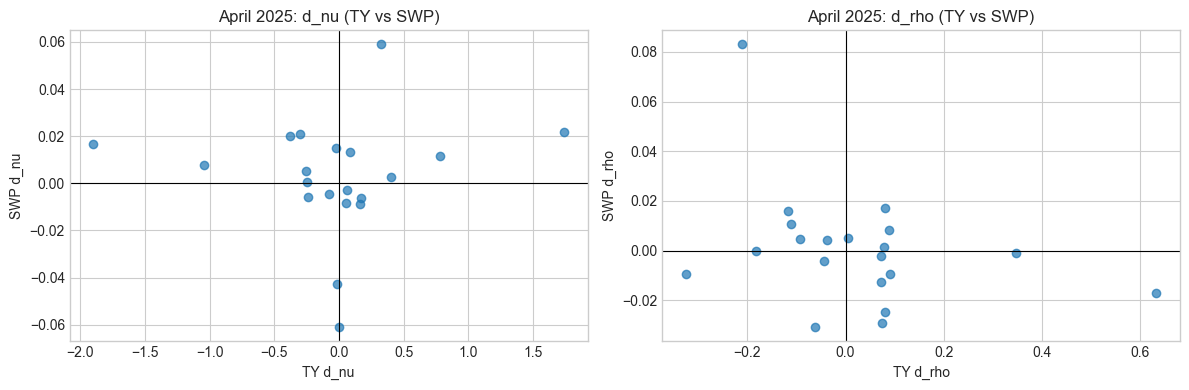

Sign agreement (nu): 0.42857142857142855
Sign agreement (rho): 0.38095238095238093
Correlation d_nu: 0.04349186170664154
Correlation d_rho: -0.33621355520316515


In [411]:
# Q4b: compare parameter changes on TY jump dates (April 2025)

# --- TY daily changes and jump metric (same construction as Q3b) ---
chg = sabr_ts.copy().sort_values(['contract', 'date'])
chg['d_alpha'] = chg.groupby('contract')['alpha'].diff()
chg['d_nu'] = chg.groupby('contract')['nu'].diff()
chg['d_rho'] = chg.groupby('contract')['rho'].diff()

# Standardize by contract-level volatility
std_alpha = chg.groupby('contract')['d_alpha'].transform('std')
std_nu = chg.groupby('contract')['d_nu'].transform('std')
std_rho = chg.groupby('contract')['d_rho'].transform('std')
std_alpha = std_alpha.replace(0, np.nan)
std_nu = std_nu.replace(0, np.nan)
std_rho = std_rho.replace(0, np.nan)

chg['z_alpha'] = chg['d_alpha'] / std_alpha
chg['z_nu'] = chg['d_nu'] / std_nu
chg['z_rho'] = chg['d_rho'] / std_rho
chg['jump_score'] = chg[['z_alpha', 'z_nu', 'z_rho']].abs().sum(axis=1)

# April 2025 only
chg_apr = chg[chg['date'].between('2025-04-01', '2025-04-30')].copy()

# Choose the largest TY jump per date (across contracts) for comparison
idx_max = chg_apr.groupby('date')['jump_score'].idxmax()
ty_jump_daily = chg_apr.loc[idx_max].sort_values('date').reset_index(drop=True)

# --- Swaption daily changes ---
swp_cmp = swp_calib.sort_values('date').copy()
swp_cmp['d_alpha'] = swp_cmp['alpha'].diff()
swp_cmp['d_nu'] = swp_cmp['nu'].diff()
swp_cmp['d_rho'] = swp_cmp['rho'].diff()

# --- Merge on date and compare ---
q4b = ty_jump_daily.merge(
    swp_cmp[['date', 'd_alpha', 'd_nu', 'd_rho']],
    on='date',
    how='inner',
    suffixes=('_TY', '_SWP')
)

q4b['same_sign_nu'] = np.sign(q4b['d_nu_TY']) == np.sign(q4b['d_nu_SWP'])
q4b['same_sign_rho'] = np.sign(q4b['d_rho_TY']) == np.sign(q4b['d_rho_SWP'])
q4b['ratio_nu'] = q4b['d_nu_SWP'] / q4b['d_nu_TY']
q4b['ratio_rho'] = q4b['d_rho_SWP'] / q4b['d_rho_TY']

# Summary view: rank by TY jump_score (largest first)
q4b_sorted = q4b.sort_values('jump_score', ascending=False)

#print('Top TY jump dates in April 2025 (by jump_score):')
#display(q4b_sorted[['date', 'contract', 'jump_score']].head(10))

print('Top TY jump dates with TY vs SWP changes:')
display(q4b_sorted[['date', 'contract', 'jump_score', 'd_nu_TY', 'd_rho_TY', 'd_nu_SWP', 'd_rho_SWP', 'same_sign_nu', 'same_sign_rho']].head(10))


# Plot: TY vs SWP daily changes (April 2025)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(q4b['d_nu_TY'], q4b['d_nu_SWP'], alpha=0.7)
axes[0].axhline(0, color='k', lw=0.8)
axes[0].axvline(0, color='k', lw=0.8)
axes[0].set_xlabel('TY d_nu')
axes[0].set_ylabel('SWP d_nu')
axes[0].set_title('April 2025: d_nu (TY vs SWP)')

axes[1].scatter(q4b['d_rho_TY'], q4b['d_rho_SWP'], alpha=0.7)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_xlabel('TY d_rho')
axes[1].set_ylabel('SWP d_rho')
axes[1].set_title('April 2025: d_rho (TY vs SWP)')

plt.tight_layout()
plt.show()
# Diagnostics
print('Sign agreement (nu):', q4b['same_sign_nu'].mean())
print('Sign agreement (rho):', q4b['same_sign_rho'].mean())
print('Correlation d_nu:', q4b[['d_nu_TY', 'd_nu_SWP']].corr().iloc[0,1])
print('Correlation d_rho:', q4b[['d_rho_TY', 'd_rho_SWP']].corr().iloc[0,1])


The largest TY smile shifts occur toward the end of April (April 28–30), where ν and ρ move sharply, while swaption parameter changes remain much smaller, indicating a smoother response in the OTC market. Directional agreement between the two markets is limited, with ν matching about 43% of the time and ρ about 38%, and correlations near zero, suggesting weak co-movement in volatility smile dynamics.


The points are scattered across all quadrants rather than aligning along a diagonal, indicating weak agreement in both direction and magnitude between the two markets. This visual pattern is consistent with the numerical results, where sign agreement is low and correlations are near zero, suggesting that volatility smile shifts in listed Treasury options are not strongly mirrored in the OTC swaption market.

#### Do the two markets agree on the direction and magnitude of and changes?

The two markets do not strongly agree on the direction or magnitude of the changes. While both markets experience movements in volatility smile parameters, the TY options market shows much larger and more abrupt shifts, and the swaption market often moves in different directions or with much smaller magnitudes.


### 4c) Normalize each product’s smile by its ATM vol on the same date and overlay them.

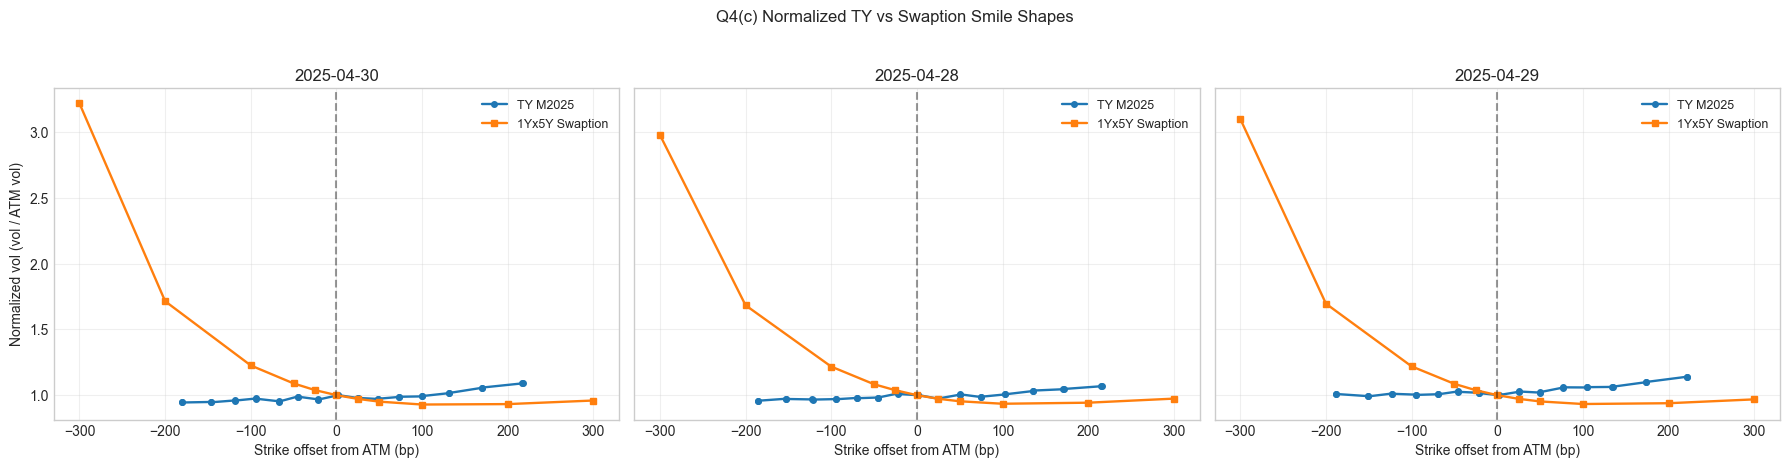

Q4(c) shape metrics (normalized smiles):


,date,TY_slope_L,TY_slope_R,SWP_slope_L,SWP_slope_R,TY_curvature,SWP_curvature,TY_tail_ratio,SWP_tail_ratio
1,2025-04-28,0.001226,0.001254,-0.001836,-0.000757,-0.011523,0.075969,0.896427,1.786842
2,2025-04-29,-0.000407,-0.000157,-0.001934,-0.000786,0.031497,0.075854,0.885081,1.807147
0,2025-04-30,-0.000878,-0.000276,-0.002033,-0.000832,-0.015639,0.077289,0.867645,1.840191


In [412]:
# 4c) Normalize each product’s smile by its ATM vol on the same date and overlay them.

# Use representative jump dates from Q4(b) if available; otherwise default to late-April dates
if 'q4b_sorted' in globals() and not q4b_sorted.empty:
    compare_dates = [pd.Timestamp(d) for d in q4b_sorted['date'].head(3)]
else:
    compare_dates = [
        pd.Timestamp('2025-04-28'),
        pd.Timestamp('2025-04-29'),
        pd.Timestamp('2025-04-30'),
    ]

ty_surf = ty_contracts['M2025'].copy()

def nearest_date_swaption(df, target_date):
    target_date = pd.Timestamp(target_date)
    i = np.argmin(np.abs(df['date'].values - target_date.to_datetime64()))
    return pd.Timestamp(df.loc[i, 'date'])

fig, axes = plt.subplots(1, len(compare_dates), figsize=(6 * len(compare_dates), 4.5), sharey=True)
if len(compare_dates) == 1:
    axes = [axes]

for ax, dt in zip(axes, compare_dates):
    # --- TY smile (use helper) ---
    d_ty = nearest_date(ty_surf, dt)
    row = ty_surf.loc[ty_surf['date'] == d_ty].iloc[0]

    F_ty = float(row['Future Price'])
    ty_atm_vol = float((row.get('P50dvol', np.nan) + row.get('C50dvol', np.nan)) / 2)

    ty_smile = build_ty_smile_from_row(row)
    # Map expected columns if helper returns strike/vol naming
    if 'K' not in ty_smile.columns and 'strike' in ty_smile.columns:
        ty_smile = ty_smile.rename(columns={'strike': 'K'})
    if 'iv' not in ty_smile.columns and 'vol' in ty_smile.columns:
        ty_smile = ty_smile.rename(columns={'vol': 'iv'})

    if 'K' not in ty_smile.columns or 'iv' not in ty_smile.columns:
        raise KeyError(f"TY smile missing columns. Found: {list(ty_smile.columns)}")

    ty_curve = ty_smile.copy()
    ty_curve['x_bp'] = (ty_curve['K'] / F_ty - 1.0) * 10000
    ty_curve['norm_vol'] = ty_curve['iv'] / ty_atm_vol

    # --- Swaption smile (use offsets directly, like Ayush) ---
    d_swp = nearest_date_swaption(swaption_merged, d_ty)
    swp_row = swaption_merged.loc[swaption_merged['date'] == d_swp].iloc[0]

    swp_vols = np.array([float(swp_row[f'{c}_vol']) for c in swaption_offsets])
    swp_atm_vol = float(swp_row['0_vol'])
    swp_curve = pd.DataFrame({
        'x_bp': np.array(swaption_offsets, dtype=float),
        'norm_vol': swp_vols / swp_atm_vol,
    }).sort_values('x_bp')

    # --- Plot ---
    ax.plot(ty_curve['x_bp'], ty_curve['norm_vol'], 'o-', lw=1.7, ms=4, label='TY M2025')
    ax.plot(swp_curve['x_bp'], swp_curve['norm_vol'], 's-', lw=1.7, ms=4, label='1Yx5Y Swaption')
    ax.axvline(0, color='black', linestyle='--', alpha=0.4)
    ax.set_title(d_ty.strftime('%Y-%m-%d'))
    ax.set_xlabel('Strike offset from ATM (bp)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Normalized vol (vol / ATM vol)')
plt.suptitle('Q4(c) Normalized TY vs Swaption Smile Shapes', y=1.03)
plt.tight_layout()
plt.show()


# --- Summary metrics per date (shape diagnostics) ---
metrics_rows = []

for dt in compare_dates:
    d_ty = nearest_date(ty_surf, dt)
    row = ty_surf.loc[ty_surf['date'] == d_ty].iloc[0]
    F_ty = float(row['Future Price'])
    ty_atm_vol = float((row.get('P50dvol', np.nan) + row.get('C50dvol', np.nan)) / 2)

    ty_smile = build_ty_smile_from_row(row)
    if 'K' not in ty_smile.columns and 'strike' in ty_smile.columns:
        ty_smile = ty_smile.rename(columns={'strike': 'K'})
    if 'iv' not in ty_smile.columns and 'vol' in ty_smile.columns:
        ty_smile = ty_smile.rename(columns={'vol': 'iv'})

    ty_curve = ty_smile.copy()
    ty_curve['x_bp'] = (ty_curve['K'] / F_ty - 1.0) * 10000
    ty_curve['norm_vol'] = ty_curve['iv'] / ty_atm_vol

    d_swp = nearest_date_swaption(swaption_merged, d_ty)
    swp_row = swaption_merged.loc[swaption_merged['date'] == d_swp].iloc[0]
    swp_vols = np.array([float(swp_row[f'{c}_vol']) for c in swaption_offsets])
    swp_atm_vol = float(swp_row['0_vol'])
    swp_curve = pd.DataFrame({
        'x_bp': np.array(swaption_offsets, dtype=float),
        'norm_vol': swp_vols / swp_atm_vol,
    }).sort_values('x_bp')

    # helper for slope using nearest offsets
    def nearest_norm(curve, x):
        i = np.argmin(np.abs(curve['x_bp'].values - x))
        return float(curve.iloc[i]['norm_vol'])

    def slope_at(curve, x0, x1):
        v0 = nearest_norm(curve, x0)
        v1 = nearest_norm(curve, x1)
        return (v1 - v0) / (x1 - x0)

    # left/right slope around ATM using 25bp and 50bp
    ty_slope_L = slope_at(ty_curve, -50.0, -25.0)
    ty_slope_R = slope_at(ty_curve, 25.0, 50.0)
    swp_slope_L = slope_at(swp_curve, -50.0, -25.0)
    swp_slope_R = slope_at(swp_curve, 25.0, 50.0)

    # curvature proxy: avg wings - ATM (use 100bp wings)
    ty_curv = 0.5 * (nearest_norm(ty_curve, -100.0) + nearest_norm(ty_curve, 100.0)) - nearest_norm(ty_curve, 0.0)
    swp_curv = 0.5 * (nearest_norm(swp_curve, -100.0) + nearest_norm(swp_curve, 100.0)) - nearest_norm(swp_curve, 0.0)

    # tail ratio: left wing / right wing at 200bp
    ty_tail = nearest_norm(ty_curve, -200.0) / nearest_norm(ty_curve, 200.0)
    swp_tail = nearest_norm(swp_curve, -200.0) / nearest_norm(swp_curve, 200.0)

    metrics_rows.append({
        'date': d_ty,
        'TY_slope_L': ty_slope_L,
        'TY_slope_R': ty_slope_R,
        'SWP_slope_L': swp_slope_L,
        'SWP_slope_R': swp_slope_R,
        'TY_curvature': ty_curv,
        'SWP_curvature': swp_curv,
        'TY_tail_ratio': ty_tail,
        'SWP_tail_ratio': swp_tail,
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values('date')

print('Q4(c) shape metrics (normalized smiles):')
display(metrics_df)


Across all three dates, the **swaption smile is much more negatively sloped on the left side** (SWP_slope_L ≈ −0.002 vs TY slopes near zero), indicating that swaption implied volatility rises much more sharply for low-strike options. The **swaption curvature and tail ratios (~1.8)** are also substantially larger than those of TY options (~0.87–0.90), showing that the swaption market places significantly more weight on extreme downside moves in rates.

#### Are the shapes similar, or do the two markets price tail risk differently?

In short, **the shapes are not similar**: the swaption market exhibits a stronger left-tail skew and greater curvature, implying that **OTC swaptions price downside interest-rate tail risk much more aggressively than Treasury futures options**.

Because **OTC swaptions are heavily used by banks and mortgage hedgers to protect against large interest-rate declines**, the market embeds stronger demand for downside protection, leading to a steeper left-tail skew than in Treasury futures options.



### 4d) Discuss possible reasons for any differences you observe.

Several factors can explain the differences between the two markets. 
- The OTC swaption market is primarily used by banks, mortgage servicers, and structured-product desks to hedge long-dated interest-rate exposures, which creates persistent demand for downside protection and leads to a stable negative skew and stronger tail pricing. 
- In contrast, Treasury futures options are exchange-traded and more heavily used for short-term macro trading and speculative positioning, which can produce more volatile SABR parameters and less stable smile dynamics. 

Differences in liquidity, market participants, and the underlying instruments (swap rates vs. Treasury futures) can therefore lead to the distinct volatility surface behavior observed between the two markets.



## Question 5: Practical Implications - Augmented Delta Across Regimes

A dealer is short a TY put struck 50 bps below ATM.

a) Compute Black delta and SABR augmented delta
$\Delta_{\text{SABR}} = \Delta_{\text{Black}} + V\,\partial\sigma/\partial F$
for one volatile date and one calm date.

b) Compare hedge-ratio correction as a percent of Black delta.

c) Connect to regime analysis and recalibration-frequency findings.


In [413]:

# Q5: augmented delta on volatile vs calm dates
# Volatile/calm proxies by ATM vol across TY calibrations.
valid = calib_all.dropna(subset=['atm_vol', 'alpha', 'rho', 'nu']).copy()
vol_row = valid.loc[valid['atm_vol'].idxmax()]
calm_row = valid.loc[valid['atm_vol'].idxmin()]

scenarios = [
    ('volatile', vol_row),
    ('calm', calm_row),
]

rows = []
for label, r in scenarios:
    c = r['contract']
    d = pd.Timestamp(r['date'])
    raw = ty_contracts[c].loc[ty_contracts[c]['date'] == d].iloc[0]

    F = float(raw['Future Price'])
    T = float(raw['Expiration Option'])
    alpha = float(r['alpha'])
    rho = float(r['rho'])
    nu = float(r['nu'])

    # Assumption: "50 bps below ATM" in TY futures price terms -> K = F - 0.50.
    K = F - 0.50

    sigma_K = float(sabr_vol(F, K, T, alpha, 0.5, rho, nu))
    delta_black = black_delta_futures(F, K, sigma_K, T, cp='P')
    vega = black_vega_futures(F, K, sigma_K, T)

    eps = 0.01
    sigma_up = float(sabr_vol(F + eps, K, T, alpha, 0.5, rho, nu))
    sigma_dn = float(sabr_vol(F - eps, K, T, alpha, 0.5, rho, nu))
    dsdF = (sigma_up - sigma_dn) / (2 * eps)

    delta_aug = delta_black + vega * dsdF
    corr_pct = 100.0 * (delta_aug - delta_black) / (abs(delta_black) + 1e-12)

    rows.append({
        'regime': label,
        'contract': c,
        'date': d.date(),
        'F': F,
        'K': K,
        'T': T,
        'sigma(K)': sigma_K,
        'delta_black_put': delta_black,
        'vega': vega,
        'dSigma_dF': dsdF,
        'delta_augmented': delta_aug,
        'correction_pct_of_|delta_black|': corr_pct,
    })

q5_table = pd.DataFrame(rows)
q5_table


,regime,contract,date,F,K,T,sigma(K),delta_black_put,vega,dSigma_dF,delta_augmented,correction_pct_of_|delta_black|
0,volatile,M2025,2025-04-11,109.734375,109.234375,0.115644,0.084936,-0.431501,14.667243,0.000703,-0.421185,2.390699
1,calm,H2026,2026-02-04,111.609375,111.109375,0.044411,0.035485,-0.272868,7.817973,0.003503,-0.245484,10.035316



## Brief Wrap-Up (Draft)

- Daily SABR calibration with ATM pinning recovers stable parameter series in calm periods and larger $(\nu,\rho)$ jumps in event windows.
- Calibration quality (RMSE) can be tracked jointly with ATM vol to identify when a simple smile parameter set is stressed.
- In the Jan-Feb 2026 overlap, same-date H2026 vs M2026 differences isolate maturity effects in smile shape.
- Cross-product comparison (TY vs 1Yx5Y swaption) shows where macro repricing is common vs product-specific.
- Augmented delta can materially differ from Black delta in high-volatility regimes; this links directly to recalibration frequency risk.

Use this scaffold to refine interpretations and tune calibration settings if needed (initial guesses, bounds, weighting, date selection).
